In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('2b. CSV raw dataset.csv', encoding='latin-1')

print("data shape:", df.shape)
print("\nfirst 30 column names:")
print(df.columns.tolist()[:30])

data shape: (3513, 342)

first 30 column names:
['panelid_2', 'Panel_PSU', 'Panel_Strata', 'Nov24_Weight', 'Nov24_IntDate', 'Nov24_IntMode', 'Cur_GOR', 'cur_urbanruraltot', 'Cur_Sex', 'Cur_AgeCat', 'Cur_HEdQual', 'Cur_Ethnic6', 'Cur_disact2', 'Cur_IntUse3', 'Cur_PartyID5', 'Cur_IdentClass', 'Cur_RelStat5', 'Cur_Tenure5', 'Cur_EconAct5', 'Cur_RClassGp', 'Cur_SubjInc', 'Cur_HHIncome4_21', 'Cur_HHIncomeEquiv4_21', 'Cur_HHSize5', 'Cur_HHChild', 'Cur_HHType', 'DigAccess', 'DigSkills01', 'DigSkills02', 'DigSkills03']


In [2]:
# define the 8 domain variables (benefit and concern for each domain)
domain_vars = {
    'FR':       ('BenFR',      'ConFR'),       # face recognition, policing
    'WB':       ('BenWB',      'ConWB'),        # welfare benefits
    'Cancer':   ('BenCancer',  'ConCancer'),    # cancer prediction
    'Loan':     ('BenLoan',    'ConLoan'),      # loan risk
    'LLM':      ('BenLLM',     'ConLLM'),       # large language models
    'Chatbot':  ('BenChatbot', 'ConChatbot'),   # mental health chatbot
    'RoboCare': ('BenRoboCare','ConRoboCare'),  # robotic care assistants
    'Car':      ('BenCar',     'ConCar'),       # driverless cars
}

# demographic variables
demo_vars = ['Cur_Sex', 'Cur_AgeCat', 'Cur_HEdQual', 'Cur_GOR',
             'Cur_PartyID5', 'Cur_RClassGp', 'Cur_EconAct5']

# weight variable
weight_var = 'Nov24_Weight'

# collect all attitude variable names into a flat list
attitude_vars = [v for pair in domain_vars.values() for v in pair]

# select only the columns we need
cols_needed = ['panelid_2', weight_var] + attitude_vars + demo_vars
df_subset = df[cols_needed].copy()

# replace all negative values (missing codes: -1, -8, -9, -11) with NaN
df_subset[attitude_vars + demo_vars] = df_subset[attitude_vars + demo_vars].replace(
    [-1, -8, -9, -11], np.nan
)

print("subset shape:", df_subset.shape)
print("\n missing values per attitude variable:")
print(df_subset[attitude_vars].isnull().sum())

subset shape: (3513, 25)

 missing values per attitude variable:
BenFR          0
ConFR          0
BenWB          0
ConWB          0
BenCancer      0
ConCancer      0
BenLoan        0
ConLoan        1
BenLLM         2
ConLLM         0
BenChatbot     1
ConChatbot     2
BenRoboCare    1
ConRoboCare    2
BenCar         1
ConCar         2
dtype: int64


In [3]:
# check value distributions for all attitude variables

for domain, (ben_var, con_var) in domain_vars.items():
    print(f"\n Domain: {domain}")
    print(f"  {ben_var} (Benefit): {df_subset[ben_var].value_counts().sort_index().to_dict()}")
    print(f"  {con_var} (Concern): {df_subset[con_var].value_counts().sort_index().to_dict()}")


 Domain: FR
  BenFR (Benefit): {1: 1735, 2: 1462, 3: 137, 4: 58, 5: 121}
  ConFR (Concern): {1: 268, 2: 1107, 3: 1367, 4: 678, 5: 93}

 Domain: WB
  BenWB (Benefit): {1: 353, 2: 1300, 3: 869, 4: 394, 5: 597}
  ConWB (Concern): {1: 568, 2: 1520, 3: 902, 4: 277, 5: 246}

 Domain: Cancer
  BenCancer (Benefit): {1: 1820, 2: 1208, 3: 165, 4: 69, 5: 251}
  ConCancer (Concern): {1: 180, 2: 944, 3: 1467, 4: 723, 5: 199}

 Domain: Loan
  BenLoan (Benefit): {1: 423, 2: 1609, 3: 768, 4: 252, 5: 461}
  ConLoan (Concern): {1.0: 341, 2.0: 1393, 3.0: 1152, 4.0: 338, 5.0: 288}

 Domain: LLM
  BenLLM (Benefit): {1.0: 574, 2.0: 1560, 3.0: 461, 4.0: 195, 5.0: 721}
  ConLLM (Concern): {1: 370, 2: 1223, 3: 1070, 4: 336, 5: 514}

 Domain: Chatbot
  BenChatbot (Benefit): {1.0: 198, 2.0: 1071, 3.0: 936, 4.0: 563, 5.0: 744}
  ConChatbot (Concern): {1.0: 753, 2.0: 1399, 3.0: 760, 4.0: 225, 5.0: 374}

 Domain: RoboCare
  BenRoboCare (Benefit): {1.0: 476, 2.0: 1440, 3.0: 690, 4.0: 395, 5.0: 511}
  ConRoboCare (C

In [4]:
# replace "Don't know" (value=5) with NaN
df_subset[attitude_vars] = df_subset[attitude_vars].replace(5, np.nan)

In [5]:
# confirm cleaned distributions (1-4)
print("value counts after cleaning:")
for domain, (ben_var, con_var) in domain_vars.items():
    ben_vals = df_subset[ben_var].value_counts().sort_index().to_dict()
    con_vals = df_subset[con_var].value_counts().sort_index().to_dict()
    print(f"  {domain:8s} | Ben {ben_vals} | Con {con_vals}")

value counts after cleaning:
  FR       | Ben {1.0: 1735, 2.0: 1462, 3.0: 137, 4.0: 58} | Con {1.0: 268, 2.0: 1107, 3.0: 1367, 4.0: 678}
  WB       | Ben {1.0: 353, 2.0: 1300, 3.0: 869, 4.0: 394} | Con {1.0: 568, 2.0: 1520, 3.0: 902, 4.0: 277}
  Cancer   | Ben {1.0: 1820, 2.0: 1208, 3.0: 165, 4.0: 69} | Con {1.0: 180, 2.0: 944, 3.0: 1467, 4.0: 723}
  Loan     | Ben {1.0: 423, 2.0: 1609, 3.0: 768, 4.0: 252} | Con {1.0: 341, 2.0: 1393, 3.0: 1152, 4.0: 338}
  LLM      | Ben {1.0: 574, 2.0: 1560, 3.0: 461, 4.0: 195} | Con {1.0: 370, 2.0: 1223, 3.0: 1070, 4.0: 336}
  Chatbot  | Ben {1.0: 198, 2.0: 1071, 3.0: 936, 4.0: 563} | Con {1.0: 753, 2.0: 1399, 3.0: 760, 4.0: 225}
  RoboCare | Ben {1.0: 476, 2.0: 1440, 3.0: 690, 4.0: 395} | Con {1.0: 712, 2.0: 1357, 3.0: 929, 4.0: 234}
  Car      | Ben {1.0: 469, 2.0: 1082, 3.0: 934, 4.0: 728} | Con {1.0: 1198, 2.0: 1424, 3.0: 568, 4.0: 209}


In [6]:
# descriptive statistics for attitude variables

# * higher score = less beneficial / concerned (reversed)
# recode so that higher = more
recode_map = {1: 4, 2: 3, 3: 2, 4: 1}
for var in attitude_vars:
    df_subset[var + '_r'] = df_subset[var].map(recode_map)

recoded_vars = [v + '_r' for v in attitude_vars]

In [7]:
# summary table-mean and std for each domain, both benefit and concern
rows = []
for domain, (ben_var, con_var) in domain_vars.items():
    ben_r = ben_var + '_r'
    con_r = con_var + '_r'

    rows.append({
    'Domain':       domain,
    'Ben_mean':     round(df_subset[ben_r].mean(), 3),
    'Ben_std':      round(df_subset[ben_r].std(), 3),
    'Ben_n_valid':  df_subset[ben_r].notna().sum(),
    'Con_mean':     round(df_subset[con_r].mean(), 3),
    'Con_std':      round(df_subset[con_r].std(), 3),
    'Con_n_valid':  df_subset[con_r].notna().sum(),
})

summary = pd.DataFrame(rows).sort_values('Con_mean', ascending=False)
print("\n descriptive summary (recoded: 1=lowest, 4=highest):")
print(summary.to_string(index=False))

# updated missing value count after all cleaning
print("\n missing values per attitude variable:")
print(df_subset[recoded_vars].isnull().sum().to_string())


 descriptive summary (recoded: 1=lowest, 4=highest):
  Domain  Ben_mean  Ben_std  Ben_n_valid  Con_mean  Con_std  Con_n_valid
     Car     2.402    0.993         3213     3.062    0.873         3399
 Chatbot     2.327    0.878         2768     2.854    0.865         3137
RoboCare     2.665    0.896         3001     2.788    0.868         3232
      WB     2.553    0.872         2916     2.728    0.846         3267
     LLM     2.901    0.801         2790     2.543    0.848         2999
    Loan     2.722    0.802         3052     2.539    0.818         3224
      FR     3.437    0.655         3392     2.282    0.869         3420
  Cancer     3.465    0.691         3262     2.175    0.831         3314

 missing values per attitude variable:
BenFR_r          121
ConFR_r           93
BenWB_r          597
ConWB_r          246
BenCancer_r      251
ConCancer_r      199
BenLoan_r        461
ConLoan_r        289
BenLLM_r         723
ConLLM_r         514
BenChatbot_r     745
ConChatbot_r     3

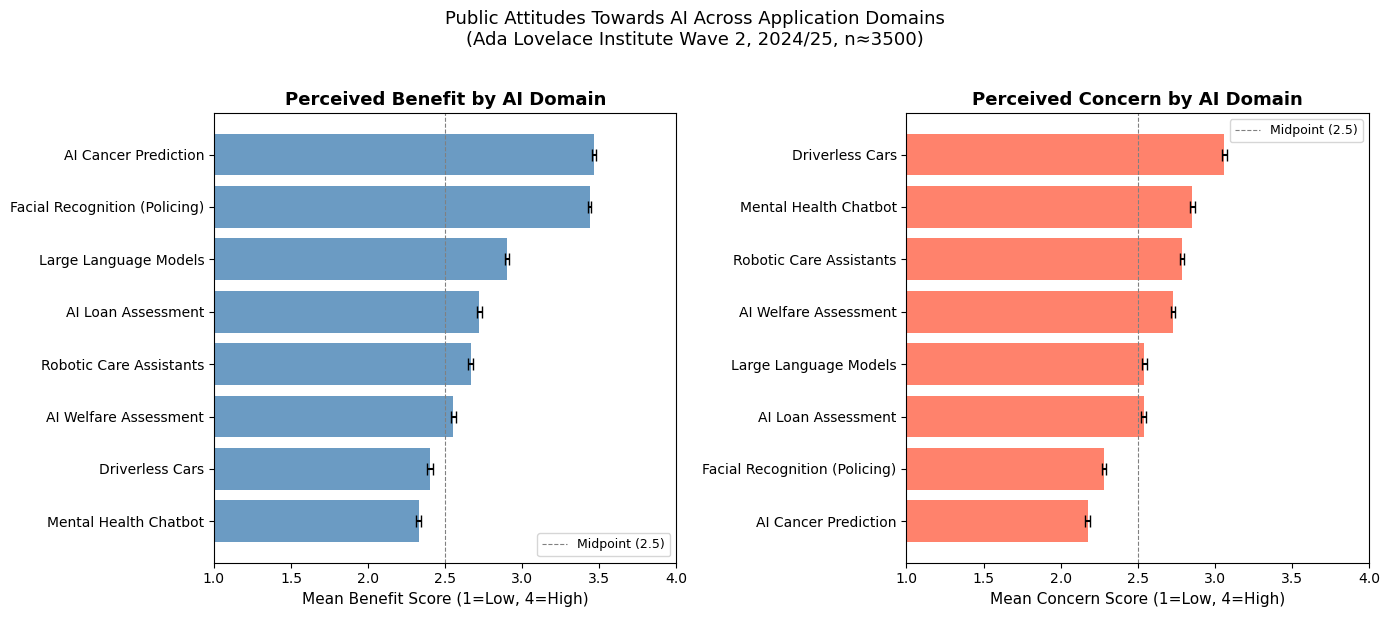

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# domain display labels
domain_labels = {
    'Cancer':   'AI Cancer Prediction',
    'FR':       'Facial Recognition (Policing)',
    'Loan':     'AI Loan Assessment',
    'LLM':      'Large Language Models',
    'RoboCare': 'Robotic Care Assistants',
    'WB':       'AI Welfare Assessment',
    'Chatbot':  'Mental Health Chatbot',
    'Car':      'Driverless Cars',
}

# sort by benefit mean descending
summary_plot = summary.copy()
summary_plot['Domain_label'] = summary_plot['Domain'].map(domain_labels)
summary_sorted_ben = summary_plot.sort_values('Ben_mean', ascending=True)
summary_sorted_con = summary_plot.sort_values('Con_mean', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# mean Benefit scores
ax1 = axes[0]
bars1 = ax1.barh(
    summary_sorted_ben['Domain_label'],
    summary_sorted_ben['Ben_mean'],
    xerr=summary_sorted_ben['Ben_std'] / np.sqrt(summary_sorted_ben['Ben_n_valid']),
    color='steelblue', alpha=0.8, capsize=4
)
ax1.set_xlim(1, 4)
ax1.axvline(x=2.5, color='grey', linestyle='--', linewidth=0.8, label='Midpoint (2.5)')
ax1.set_xlabel('Mean Benefit Score (1=Low, 4=High)', fontsize=11)
ax1.set_title('Perceived Benefit by AI Domain', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)
ax1.set_xticks([1, 1.5, 2, 2.5, 3, 3.5, 4])

# mean Concern scores
ax2 = axes[1]
bars2 = ax2.barh(
    summary_sorted_con['Domain_label'],
    summary_sorted_con['Con_mean'],
    xerr=summary_sorted_con['Con_std'] / np.sqrt(summary_sorted_con['Con_n_valid']),
    color='tomato', alpha=0.8, capsize=4
)
ax2.set_xlim(1, 4)
ax2.axvline(x=2.5, color='grey', linestyle='--', linewidth=0.8, label='Midpoint (2.5)')
ax2.set_xlabel('Mean Concern Score (1=Low, 4=High)', fontsize=11)
ax2.set_title('Perceived Concern by AI Domain', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_xticks([1, 1.5, 2, 2.5, 3, 3.5, 4])

plt.suptitle(
    'Public Attitudes Towards AI Across Application Domains\n(Ada Lovelace Institute Wave 2, 2024/25, n≈3500)',
    fontsize=13, y=1.02
)
plt.tight_layout()
#plt.savefig('1 domain attitudes.png', dpi=150, bbox_inches='tight')
plt.show()

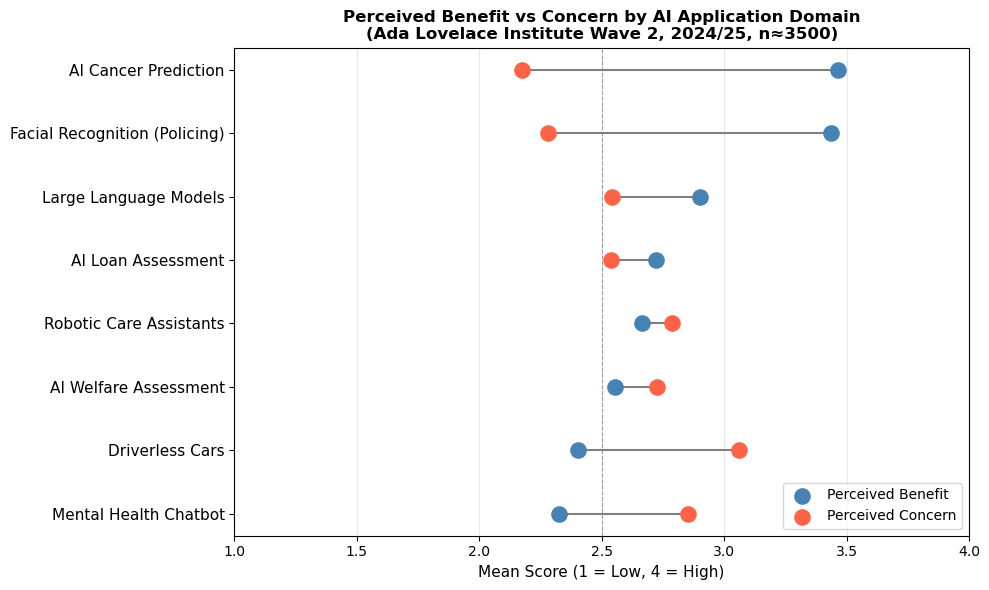

In [9]:
# benefit vs concern
# sort domains by benefit mean descending
summary_plot2 = summary_plot.sort_values('Ben_mean', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))

y_pos = np.arange(len(summary_plot2))

# draw horizontal lines connecting benefit and concern for each domain
for i, row in summary_plot2.iterrows():
    ax.plot(
        [row['Ben_mean'], row['Con_mean']],
        [i, i],
        color='grey', linewidth=1.5, zorder=1
    )

# benefit dots
ax.scatter(
    summary_plot2['Ben_mean'], y_pos,
    color='steelblue', s=120, zorder=2, label='Perceived Benefit'
)

# concern dots
ax.scatter(
    summary_plot2['Con_mean'], y_pos,
    color='tomato', s=120, zorder=2, label='Perceived Concern'
)

# error bars (standard error)
ax.errorbar(
    summary_plot2['Ben_mean'], y_pos,
    xerr=summary_plot2['Ben_std'] / np.sqrt(summary_plot2['Ben_n_valid']),
    fmt='none', color='steelblue', capsize=3, linewidth=1
)
ax.errorbar(
    summary_plot2['Con_mean'], y_pos,
    xerr=summary_plot2['Con_std'] / np.sqrt(summary_plot2['Con_n_valid']),
    fmt='none', color='tomato', capsize=3, linewidth=1
)

ax.set_yticks(y_pos)
ax.set_yticklabels(summary_plot2['Domain_label'], fontsize=11)
ax.set_xlim(1, 4)
ax.set_xticks([1, 1.5, 2, 2.5, 3, 3.5, 4])
ax.axvline(x=2.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.7)
ax.set_xlabel('Mean Score (1 = Low, 4 = High)', fontsize=11)
ax.set_title(
    'Perceived Benefit vs Concern by AI Application Domain\n'
    '(Ada Lovelace Institute Wave 2, 2024/25, n≈3500)',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=10, loc='lower right')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
#plt.savefig('2 benefit_vs_concern.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# LCA preparation

# check how many complete cases across all 16 recoded variables
complete_mask = df_subset[recoded_vars].notna().all(axis=1)
df_lca = df_subset[complete_mask].copy()

print(f"total respondents:        {len(df_subset)}")
print(f"ocmplete cases (all 16):  {len(df_lca)}")
print(f"dropped:                  {len(df_subset) - len(df_lca)}")
print(f"retention rate:           {len(df_lca)/len(df_subset)*100:.1f}%")

# check distribution of complete cases across domains
print("\nMean scores in complete-case sample vs full sample:")
print(f"{'Variable':<15} {'Full mean':>10} {'CC mean':>10} {'Diff':>8}")
for var in recoded_vars:
    full_mean = df_subset[var].mean()
    cc_mean   = df_lca[var].mean()
    print(f"{var:<15} {full_mean:>10.3f} {cc_mean:>10.3f} {cc_mean - full_mean:>8.3f}")

total respondents:        3513
ocmplete cases (all 16):  1740
dropped:                  1773
retention rate:           49.5%

Mean scores in complete-case sample vs full sample:
Variable         Full mean    CC mean     Diff
BenFR_r              3.437      3.441    0.004
ConFR_r              2.282      2.294    0.012
BenWB_r              2.553      2.569    0.016
ConWB_r              2.728      2.739    0.011
BenCancer_r          3.465      3.482    0.017
ConCancer_r          2.175      2.140   -0.036
BenLoan_r            2.722      2.754    0.032
ConLoan_r            2.539      2.551    0.012
BenLLM_r             2.901      2.930    0.029
ConLLM_r             2.543      2.567    0.025
BenChatbot_r         2.327      2.347    0.020
ConChatbot_r         2.854      2.847   -0.008
BenRoboCare_r        2.665      2.729    0.063
ConRoboCare_r        2.788      2.760   -0.028
BenCar_r             2.402      2.524    0.121
ConCar_r             3.062      3.019   -0.043


In [12]:
# try handle missing data with Multiple Imputation
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# use only the 16 recoded attitude variables for imputation
X_raw = df_subset[recoded_vars].copy()

imputer = IterativeImputer(
    max_iter=50,
    random_state=42,
    min_value=1,   # enforce scale bounds
    max_value=4,
    tol=1e-3
)

X_imputed_array = imputer.fit_transform(X_raw)
df_imputed = pd.DataFrame(X_imputed_array, columns=recoded_vars, index=df_subset.index)

# round to nearest integer to keep ordinal scale
df_imputed = df_imputed.round().astype(int)

# attach back to main subset
df_lca = df_subset.copy()
df_lca[recoded_vars] = df_imputed

# verify
print("Missing values after imputation:")
print(df_lca[recoded_vars].isnull().sum().sum())

print("\nValue range check (should be 1-4 for all):")
print(df_lca[recoded_vars].min().min(), "to", df_lca[recoded_vars].max().max())

print("\nMean comparison (original vs imputed, full n=3513):")
print(f"{'Variable':<15} {'Original':>10} {'Imputed':>10} {'Diff':>8}")
for var in recoded_vars:
    orig = df_subset[var].mean()
    imp  = df_lca[var].mean()
    print(f"{var:<15} {orig:>10.3f} {imp:>10.3f} {imp - orig:>8.3f}")

Missing values after imputation:
0

Value range check (should be 1-4 for all):
1 to 4

Mean comparison (original vs imputed, full n=3513):
Variable          Original    Imputed     Diff
BenFR_r              3.437      3.425   -0.012
ConFR_r              2.282      2.286    0.003
BenWB_r              2.553      2.553    0.001
ConWB_r              2.728      2.726   -0.002
BenCancer_r          3.465      3.447   -0.018
ConCancer_r          2.175      2.180    0.004
BenLoan_r            2.722      2.716   -0.006
ConLoan_r            2.539      2.540    0.002
BenLLM_r             2.901      2.872   -0.029
ConLLM_r             2.543      2.553    0.010
BenChatbot_r         2.327      2.313   -0.014
ConChatbot_r         2.854      2.850   -0.005
BenRoboCare_r        2.665      2.640   -0.025
ConRoboCare_r        2.788      2.787   -0.001
BenCar_r             2.402      2.396   -0.006
ConCar_r             3.062      3.060   -0.002


In [13]:
# LCA: fit k=2 to k=6
from stepmix.stepmix import StepMix
import warnings
warnings.filterwarnings('ignore')

X_lca = df_lca[recoded_vars].values

fit_results = []

for k in range(2, 7):
    best_bic = np.inf
    best_model = None

    # run 10 random starts, keep best
    for seed in range(10):
        model = StepMix(
            n_components=k,
            measurement='categorical',
            n_init=1,
            max_iter=500,
            random_state=seed,
            progress_bar=False
        )
        model.fit(X_lca)
        bic = model.bic(X_lca)
        if bic < best_bic:
            best_bic = bic
            best_model = model

    aic       = best_model.aic(X_lca)
    bic       = best_model.bic(X_lca)
    log_lik   = best_model.score(X_lca) * len(X_lca)

    # measures classification certainty (closer to 1 = better)
    probs     = best_model.predict_proba(X_lca)
    entropy   = 1 + (np.sum(probs * np.log(probs + 1e-10))) / (len(X_lca) * np.log(k))

    fit_results.append({
        'k':        k,
        'AIC':      round(aic, 1),
        'BIC':      round(bic, 1),
        'LogLik':   round(log_lik, 1),
        'Entropy':  round(entropy, 3),
        'model':    best_model
    })
    print(f"k={k}  AIC={aic:.1f}  BIC={bic:.1f}  Entropy={entropy:.3f}")

fit_df = pd.DataFrame(fit_results).drop(columns='model')
print("\nFit index summary:")
print(fit_df.to_string(index=False))

k=2  AIC=123655.8  BIC=124450.9  Entropy=0.812
k=3  AIC=120072.9  BIC=121268.8  Entropy=0.818
k=4  AIC=118536.8  BIC=120133.4  Entropy=0.808
k=5  AIC=117533.0  BIC=119530.2  Entropy=0.816
k=6  AIC=116597.9  BIC=118995.8  Entropy=0.813

Fit index summary:
 k      AIC      BIC   LogLik  Entropy
 2 123655.8 124450.9 -61698.9    0.812
 3 120072.9 121268.8 -59842.5    0.818
 4 118536.8 120133.4 -59009.4    0.808
 5 117533.0 119530.2 -58442.5    0.816
 6 116597.9 118995.8 -57910.0    0.813


In [14]:
# extend search to k=7 and k=8
for k in range(7, 9):
    best_bic = np.inf
    best_model = None

    for seed in range(10):
        model = StepMix(
            n_components=k,
            measurement='categorical',
            n_init=1,
            max_iter=500,
            random_state=seed,
            progress_bar=False
        )
        model.fit(X_lca)
        bic = model.bic(X_lca)
        if bic < best_bic:
            best_bic = bic
            best_model = model

    aic      = best_model.aic(X_lca)
    bic      = best_model.bic(X_lca)
    log_lik  = best_model.score(X_lca) * len(X_lca)
    probs    = best_model.predict_proba(X_lca)
    entropy  = 1 + (np.sum(probs * np.log(probs + 1e-10))) / (len(X_lca) * np.log(k))

    fit_results.append({
        'k':       k,
        'AIC':     round(aic, 1),
        'BIC':     round(bic, 1),
        'LogLik':  round(log_lik, 1),
        'Entropy': round(entropy, 3),
        'model':   best_model
    })
    print(f"k={k}  AIC={aic:.1f}  BIC={bic:.1f}  Entropy={entropy:.3f}")

fit_df = pd.DataFrame(fit_results).drop(columns='model')

k=7  AIC=116039.0  BIC=118837.5  Entropy=0.810
k=8  AIC=115662.9  BIC=118862.2  Entropy=0.803


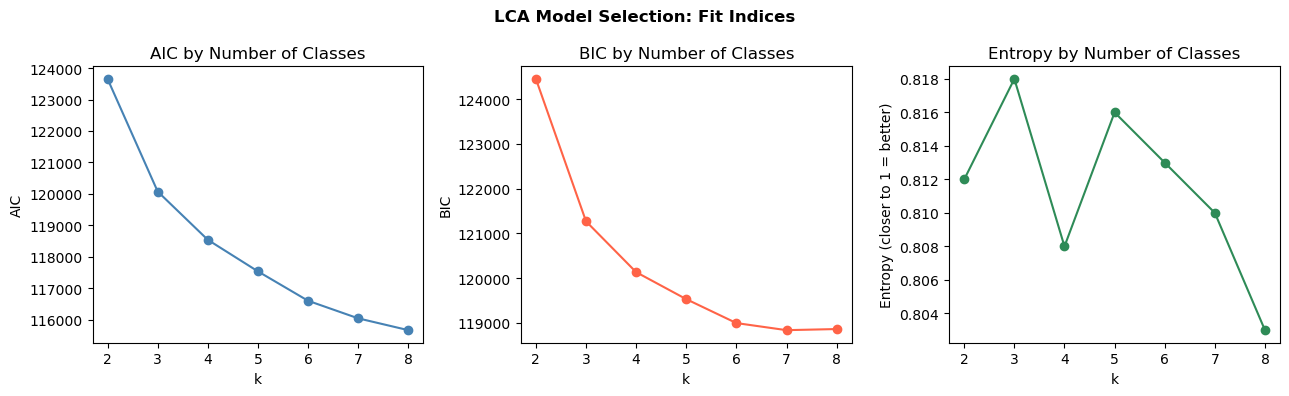


 Updated fit index summary:
 k      AIC      BIC   LogLik  Entropy
 2 123655.8 124450.9 -61698.9    0.812
 3 120072.9 121268.8 -59842.5    0.818
 4 118536.8 120133.4 -59009.4    0.808
 5 117533.0 119530.2 -58442.5    0.816
 6 116597.9 118995.8 -57910.0    0.813
 7 116039.0 118837.5 -57565.5    0.810
 8 115662.9 118862.2 -57312.5    0.803


In [15]:
# elbow plot
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].plot(fit_df['k'], fit_df['AIC'], marker='o', color='steelblue')
axes[0].set_title('AIC by Number of Classes')
axes[0].set_xlabel('k')
axes[0].set_ylabel('AIC')
axes[0].set_xticks(fit_df['k'])

axes[1].plot(fit_df['k'], fit_df['BIC'], marker='o', color='tomato')
axes[1].set_title('BIC by Number of Classes')
axes[1].set_xlabel('k')
axes[1].set_ylabel('BIC')
axes[1].set_xticks(fit_df['k'])

axes[2].plot(fit_df['k'], fit_df['Entropy'], marker='o', color='seagreen')
axes[2].set_title('Entropy by Number of Classes')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Entropy (closer to 1 = better)')
axes[2].set_xticks(fit_df['k'])

plt.suptitle('LCA Model Selection: Fit Indices', fontsize=12, fontweight='bold')
plt.tight_layout()
#plt.savefig('3 lca_fit indices.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Updated fit index summary:")
print(fit_df.to_string(index=False))

In [16]:
# fit final models for k=3 and k=5, examine

def fit_best_model(X, k, n_seeds=20):
    """Fit LCA with multiple random seeds, return best model by BIC."""
    best_bic = np.inf
    best_model = None
    for seed in range(n_seeds):
        model = StepMix(
            n_components=k,
            measurement='categorical',
            n_init=1,
            max_iter=500,
            random_state=seed,
            progress_bar=False
        )
        model.fit(X)
        bic = model.bic(X)
        if bic < best_bic:
            best_bic = bic
            best_model = model
    return best_model

model_k3 = fit_best_model(X_lca, k=3, n_seeds=20)
model_k5 = fit_best_model(X_lca, k=5, n_seeds=20)

# class size distribution
for k, model in [(3, model_k3), (5, model_k5)]:
    labels = model.predict(X_lca)
    sizes  = pd.Series(labels).value_counts(normalize=True).sort_index()
    print(f"\nk={k} class sizes:")
    for cls, prop in sizes.items():
        print(f"  Class {cls+1}: {prop*100:.1f}%")


k=3 class sizes:
  Class 1: 31.6%
  Class 2: 43.9%
  Class 3: 24.6%

k=5 class sizes:
  Class 1: 12.4%
  Class 2: 27.8%
  Class 3: 11.8%
  Class 4: 27.3%
  Class 5: 20.7%


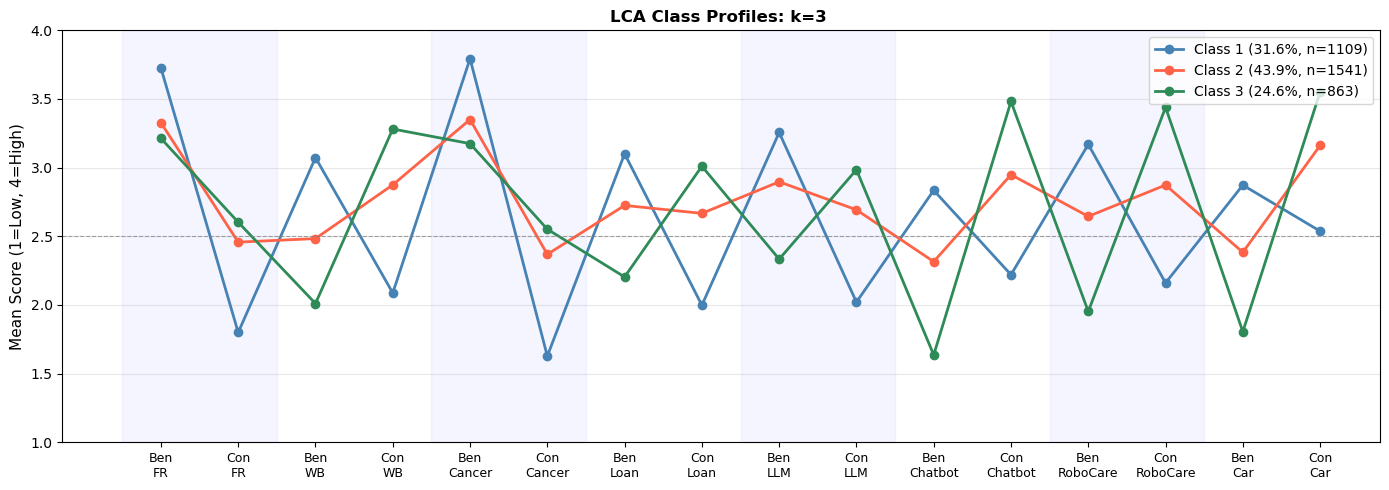

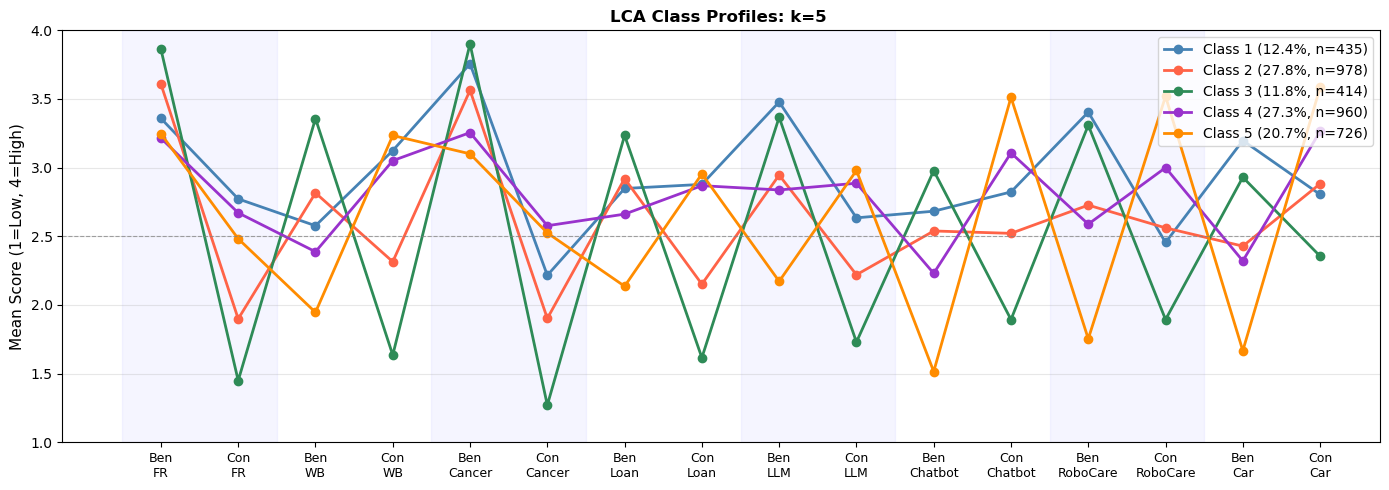

In [17]:
# plot class profiles for k=3
def plot_class_profiles(model, k, X, recoded_vars, domain_labels, title_suffix):
    labels     = model.predict(X)
    n_per_class = pd.Series(labels).value_counts().sort_index()

    # Compute mean score per class per variable
    df_prof = pd.DataFrame(X, columns=recoded_vars)
    df_prof['class'] = labels

    # Short variable labels for plot
    short_labels = [
        'Ben\nFR', 'Con\nFR', 'Ben\nWB', 'Con\nWB',
        'Ben\nCancer', 'Con\nCancer', 'Ben\nLoan', 'Con\nLoan',
        'Ben\nLLM', 'Con\nLLM', 'Ben\nChatbot', 'Con\nChatbot',
        'Ben\nRoboCare', 'Con\nRoboCare', 'Ben\nCar', 'Con\nCar'
    ]

    colors = ['steelblue', 'tomato', 'seagreen', 'darkorchid', 'darkorange']
    fig, ax = plt.subplots(figsize=(14, 5))

    x = np.arange(len(recoded_vars))
    for cls in range(k):
        mask   = df_prof['class'] == cls
        means  = df_prof.loc[mask, recoded_vars].mean().values
        n      = n_per_class[cls]
        pct    = n / len(X) * 100
        ax.plot(x, means, marker='o', color=colors[cls],
                linewidth=2, markersize=6,
                label=f'Class {cls+1} ({pct:.1f}%, n={n})')
        
    ax.set_xticks(x)
    ax.set_xticklabels(short_labels, fontsize=9)
    ax.set_ylim(1, 4)
    ax.axhline(y=2.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.set_ylabel('Mean Score (1=Low, 4=High)', fontsize=11)
    ax.set_title(f'LCA Class Profiles: k={k} {title_suffix}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10, loc='upper right')
    ax.grid(axis='y', alpha=0.3)

    # shade benefit vs concern regions alternately
    for i in range(0, 16, 4):
        ax.axvspan(i-0.5, i+1.5, alpha=0.04, color='blue')

    plt.tight_layout()
    #plt.savefig(f'4 lca_profiles_k{k}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_class_profiles(model_k3, 3, X_lca, recoded_vars, domain_labels, '')
plot_class_profiles(model_k5, 5, X_lca, recoded_vars, domain_labels, '')

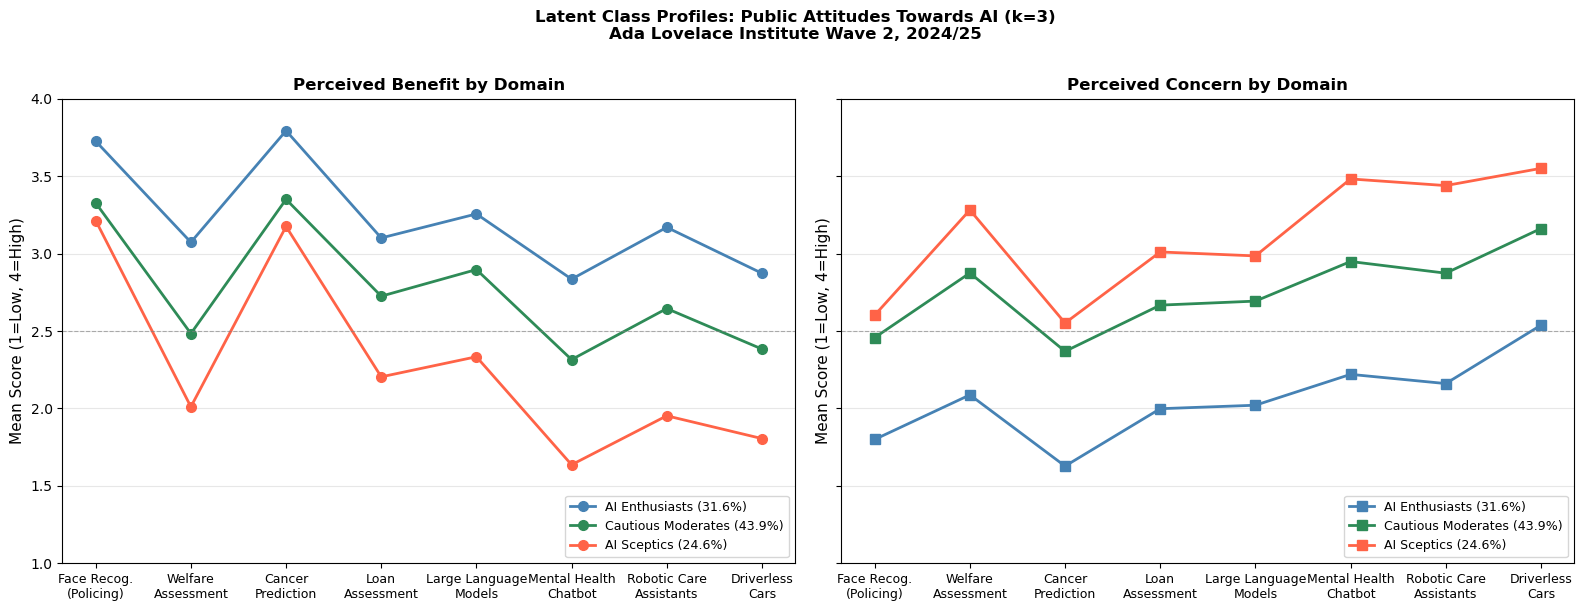


Class profile means (recoded 1=Low, 4=High):
Variable             Class 1     Class 2     Class 3
BenFR_r                3.726       3.327       3.213
ConFR_r                1.800       2.457       2.603
BenWB_r                3.073       2.483       2.010
ConWB_r                2.087       2.875       3.282
BenCancer_r            3.794       3.350       3.175
ConCancer_r            1.628       2.369       2.552
BenLoan_r              3.101       2.725       2.204
ConLoan_r              1.998       2.667       3.010
BenLLM_r               3.256       2.897       2.334
ConLLM_r               2.021       2.693       2.985
BenChatbot_r           2.835       2.315       1.636
ConChatbot_r           2.220       2.949       3.482
BenRoboCare_r          3.170       2.645       1.952
ConRoboCare_r          2.161       2.873       3.439
BenCar_r               2.873       2.384       1.805
ConCar_r               2.537       3.162       3.550


In [32]:
# final choose k=3, publication-quality profile plot

# re-extract class assignments from k=3 model
labels_k3 = model_k3.predict(X_lca)
df_lca['LCA_class'] = labels_k3 + 1  # make classes 1-indexed

# class labels based on interpretation
class_names = {
    1: 'AI Enthusiasts (31.6%)',
    2: 'Cautious Moderates (43.9%)',
    3: 'AI Sceptics (24.6%)'
}
class_colors = {1: 'steelblue', 2: 'seagreen', 3: 'tomato'}

# compute class-level means for each variable
df_prof = pd.DataFrame(X_lca, columns=recoded_vars)
df_prof['class'] = labels_k3 + 1

# xaxis: group by domain (benefit then concern)
domain_order = ['FR', 'WB', 'Cancer', 'Loan', 'LLM', 'Chatbot', 'RoboCare', 'Car']
domain_full  = ['Face Recog.\n(Policing)', 'Welfare\nAssessment',
                'Cancer\nPrediction', 'Loan\nAssessment',
                'Large Language\nModels', 'Mental Health\nChatbot',
                'Robotic Care\nAssistants', 'Driverless\nCars']

ben_vars = [f'Ben{d}_r' for d in domain_order]
con_vars = [f'Con{d}_r' for d in domain_order]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, vars_list, panel_title, marker in zip(
    axes,
    [ben_vars, con_vars],
    ['Perceived Benefit by Domain', 'Perceived Concern by Domain'],
    ['o', 's']
):
    x = np.arange(len(domain_order))
    for cls in [1, 2, 3]:
        mask  = df_prof['class'] == cls
        means = df_prof.loc[mask, vars_list].mean().values
        ax.plot(x, means, marker=marker,
                color=class_colors[cls], linewidth=2, markersize=7,
                label=class_names[cls])

    ax.set_xticks(x)
    ax.set_xticklabels(domain_full, fontsize=9)
    ax.set_ylim(1, 4)
    ax.axhline(y=2.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.set_ylabel('Mean Score (1=Low, 4=High)', fontsize=11)
    ax.set_title(panel_title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle(
    'Latent Class Profiles: Public Attitudes Towards AI (k=3)\n'
    'Ada Lovelace Institute Wave 2, 2024/25',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
#plt.savefig('5 lca_k3_final.png', dpi=150, bbox_inches='tight')
plt.show()

# Print class-level mean table
print("\nClass profile means (recoded 1=Low, 4=High):")
header = f"{'Variable':<16}" + "".join([f"{'Class '+str(c):>12}" for c in [1,2,3]])
print(header)
for var in recoded_vars:
    row = f"{var:<16}"
    for cls in [1, 2, 3]:
        m = df_prof.loc[df_prof['class']==cls, var].mean()
        row += f"{m:>12.3f}"
    print(row)

In [33]:
class_label_map = {
    1: 'AI Enthusiasts',
    2: 'Cautious Moderates',
    3: 'AI Sceptics'
}
df_lca['LCA_class_label'] = df_lca['LCA_class'].map(class_label_map)

# posterior probabilities
posterior_probs = model_k3.predict_proba(X_lca)
df_lca['prob_class1'] = posterior_probs[:, 0]
df_lca['prob_class2'] = posterior_probs[:, 1]
df_lca['prob_class3'] = posterior_probs[:, 2]

# average posterior probability per class
print("average posterior probability per class (higher = cleaner separation):")
for cls in [1, 2, 3]:
    mask = df_lca['LCA_class'] == cls
    avg_prob = df_lca.loc[mask, f'prob_class{cls}'].mean()
    print(f"  {class_label_map[cls]:<22}: {avg_prob:.3f}")

# summary
print("\nFinal class sizes:")
print(df_lca['LCA_class_label'].value_counts())

# Save the working dataset
#df_lca.to_csv('ada_lca_results.csv', index=False)
print("Columns saved:", df_lca.shape)

average posterior probability per class (higher = cleaner separation):
  AI Enthusiasts        : 0.924
  Cautious Moderates    : 0.913
  AI Sceptics           : 0.915

Final class sizes:
LCA_class_label
Cautious Moderates    1541
AI Enthusiasts        1109
AI Sceptics            863
Name: count, dtype: int64
Columns saved: (3513, 46)


In [34]:
# multinomial logistic regression demographic predictors of LCA class
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel

# use statsmodels MNLogit for interpretable coefficients and p-values
# reference category: Cautious Moderates (largest class)

# select demographic variables and drop rows with missing demographics
demo_vars_used = ['Cur_Sex', 'Cur_AgeCat', 'Cur_HEdQual',
                  'Cur_PartyID5', 'Cur_RClassGp', 'Cur_EconAct5']

df_reg = df_lca[demo_vars_used + ['LCA_class']].copy()

# replace negative codes with NaN in demo vars
df_reg[demo_vars_used] = df_reg[demo_vars_used].replace([-1, -8, -9, -11], np.nan)
df_reg = df_reg.dropna()

print(f"Regression sample size: {len(df_reg)}")
print(f"class distribution in regression sample:")
print(df_reg['LCA_class'].value_counts().sort_index())

# recode class so Cautious Moderates (class 2) becomes the reference
# map: original 2 to 0 (ref), original 1 to 1, original 3 to 2
class_recode_for_ref = {2: 0, 1: 1, 3: 2}
y = df_reg['LCA_class'].map(class_recode_for_ref).astype(int)

#   y = 0 (reference) ← original LCA class 2 = Cautious Moderates
#   y = 1             ← original LCA class 1 = AI Enthusiasts
#   y = 2             ← original LCA class 3 = AI Sceptics

X_reg = pd.get_dummies(
    df_reg[demo_vars_used].astype(str),
    drop_first=True,   # drop first category as reference
    dtype=float
)
X_reg = sm.add_constant(X_reg)

# fit multinomial logistic regression
mnlogit = sm.MNLogit(y, X_reg)
result  = mnlogit.fit(method='bfgs', maxiter=500, disp=False)

print("\nMNLogit Summary (reference class = Cautious Moderates):")
print(result.summary())

Regression sample size: 3412
class distribution in regression sample:
LCA_class
1    1090
2    1496
3     826
Name: count, dtype: int64

MNLogit Summary (reference class = Cautious Moderates):
                          MNLogit Regression Results                          
Dep. Variable:              LCA_class   No. Observations:                 3412
Model:                        MNLogit   Df Residuals:                     3364
Method:                           MLE   Df Model:                           46
Date:                Tue, 25 Aug 2026   Pseudo R-squ.:                 0.02748
Time:                        04:42:24   Log-Likelihood:                -3548.7
converged:                       True   LL-Null:                       -3648.9
Covariance Type:            nonrobust   LLR p-value:                 3.450e-21
     LCA_class=1       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const

In [35]:
# confirm structure of params, conf, pvals after recode
params = result.params
conf   = result.conf_int()
pvals  = result.pvalues

print("params columns:", params.columns.tolist())
print("conf index (first 5):", conf.index[:5].tolist())
print("pvals columns:", pvals.columns.tolist())

params columns: [0, 1]
conf index (first 5): [('1', 'const'), ('1', 'Cur_Sex_2.0'), ('1', 'Cur_AgeCat_2.0'), ('1', 'Cur_AgeCat_3.0'), ('1', 'Cur_AgeCat_4.0')]
pvals columns: [0, 1]


In [36]:
# Odds Ratio plot

params = result.params
conf   = result.conf_int()    # MultiIndex: (class, variable)
pvals  = result.pvalues

# Variable name mapping for readable labels
var_labels = {
    'const':             'Intercept',
    # Cur_Sex: 1=Female (reference), 2=Male
    'Cur_Sex_2.0':       'Sex: Male (ref=Female)',
    # Cur_AgeCat: 1=18-29 (reference), 2=30-39, 3=40-49, 4=50-59, 5=60-69, 6=70+
    'Cur_AgeCat_2.0':    'Age: 30-39',
    'Cur_AgeCat_3.0':    'Age: 40-49',
    'Cur_AgeCat_4.0':    'Age: 50-59',
    'Cur_AgeCat_5.0':    'Age: 60-69',
    'Cur_AgeCat_6.0':    'Age: 70+',
    # Cur_HEdQual: 1=Degree (reference)
    'Cur_HEdQual_2.0':   'Education: A-level / Voc L3',
    'Cur_HEdQual_3.0':   'Education: Below A-level',
    'Cur_HEdQual_4.0':   'Education: Other qualification',
    'Cur_HEdQual_5.0':   'Education: No qualifications',
    # Cur_PartyID5: 1=Conservative (reference), 2=Labour, 3=Lib Dem, 4=Other, 5=None
    'Cur_PartyID5_2.0':  'Party: Labour',
    'Cur_PartyID5_3.0':  'Party: Liberal Democrat',
    'Cur_PartyID5_4.0':  'Party: Other party',
    'Cur_PartyID5_5.0':  'Party: None / No ID',
    # Cur_RClassGp: NS-SEC analytic, 1=Managerial & professional (reference)
    'Cur_RClassGp_2.0':  'NS-SEC: Intermediate',
    'Cur_RClassGp_3.0':  'NS-SEC: Small employers / self-emp.',
    'Cur_RClassGp_4.0':  'NS-SEC: Lower supervisory / technical',
    'Cur_RClassGp_5.0':  'NS-SEC: Semi-routine / routine',
    'Cur_RClassGp_8.0':  'NS-SEC: Not classifiable',
    # Cur_EconAct5: 1=Full-time education (reference)
    'Cur_EconAct5_2.0':  'Econ: Paid work',
    'Cur_EconAct5_3.0':  'Econ: Unemployed',
    'Cur_EconAct5_4.0':  'Econ: Retired',
    'Cur_EconAct5_5.0':  'Econ: Other',
}

# Plot odds ratios for both comparisons (Cautious Moderates as reference)

comparison_labels = ['AI Enthusiasts vs Cautious Moderates',
                     'AI Sceptics vs Cautious Moderates']
# MNLogit: class=2 is Enthusiasts, class=1 is Sceptics
# params columns: 0=class1 (Sceptics), 1=class3..
print("Params shape:", params.shape)
print("Params columns:", params.columns.tolist())

Params shape: (24, 2)
Params columns: [0, 1]


In [37]:
print("Params columns:", params.columns.tolist())
print("Unique LCA classes:", sorted(df_reg['LCA_class'].unique()))
print("\nparams column 0:")
print(params[0].head())
print("\nparams column 1:")
print(params[1].head())

print("---conf structure----")
print("Type:", type(conf))
print("Shape:", conf.shape)
print("Index type:", type(conf.index))
print("Index (first 10):", conf.index[:10].tolist())
print("Columns:", conf.columns.tolist())
print()
print("-----pvals structure------")
print("Type:", type(pvals))
print("Shape:", pvals.shape)
print("Index (first 5):", pvals.index[:5].tolist())
print("Columns:", pvals.columns.tolist())
print()
print("------conf first 6 rows-------")
print(conf.head(6))

Params columns: [0, 1]
Unique LCA classes: [np.int64(1), np.int64(2), np.int64(3)]

params column 0:
const            -0.612613
Cur_Sex_2.0       0.667677
Cur_AgeCat_2.0    0.119454
Cur_AgeCat_3.0    0.105650
Cur_AgeCat_4.0    0.058996
Name: 0, dtype: float64

params column 1:
const            -0.928470
Cur_Sex_2.0       0.104024
Cur_AgeCat_2.0   -0.104761
Cur_AgeCat_3.0    0.049327
Cur_AgeCat_4.0    0.240627
Name: 1, dtype: float64
---conf structure----
Type: <class 'pandas.core.frame.DataFrame'>
Shape: (48, 2)
Index type: <class 'pandas.core.indexes.multi.MultiIndex'>
Index (first 10): [('1', 'const'), ('1', 'Cur_Sex_2.0'), ('1', 'Cur_AgeCat_2.0'), ('1', 'Cur_AgeCat_3.0'), ('1', 'Cur_AgeCat_4.0'), ('1', 'Cur_AgeCat_5.0'), ('1', 'Cur_AgeCat_6.0'), ('1', 'Cur_HEdQual_2.0'), ('1', 'Cur_HEdQual_3.0'), ('1', 'Cur_HEdQual_4.0')]
Columns: ['lower', 'upper']

-----pvals structure------
Type: <class 'pandas.core.frame.DataFrame'>
Shape: (24, 2)
Index (first 5): ['const', 'Cur_Sex_2.0', 'Cur_A

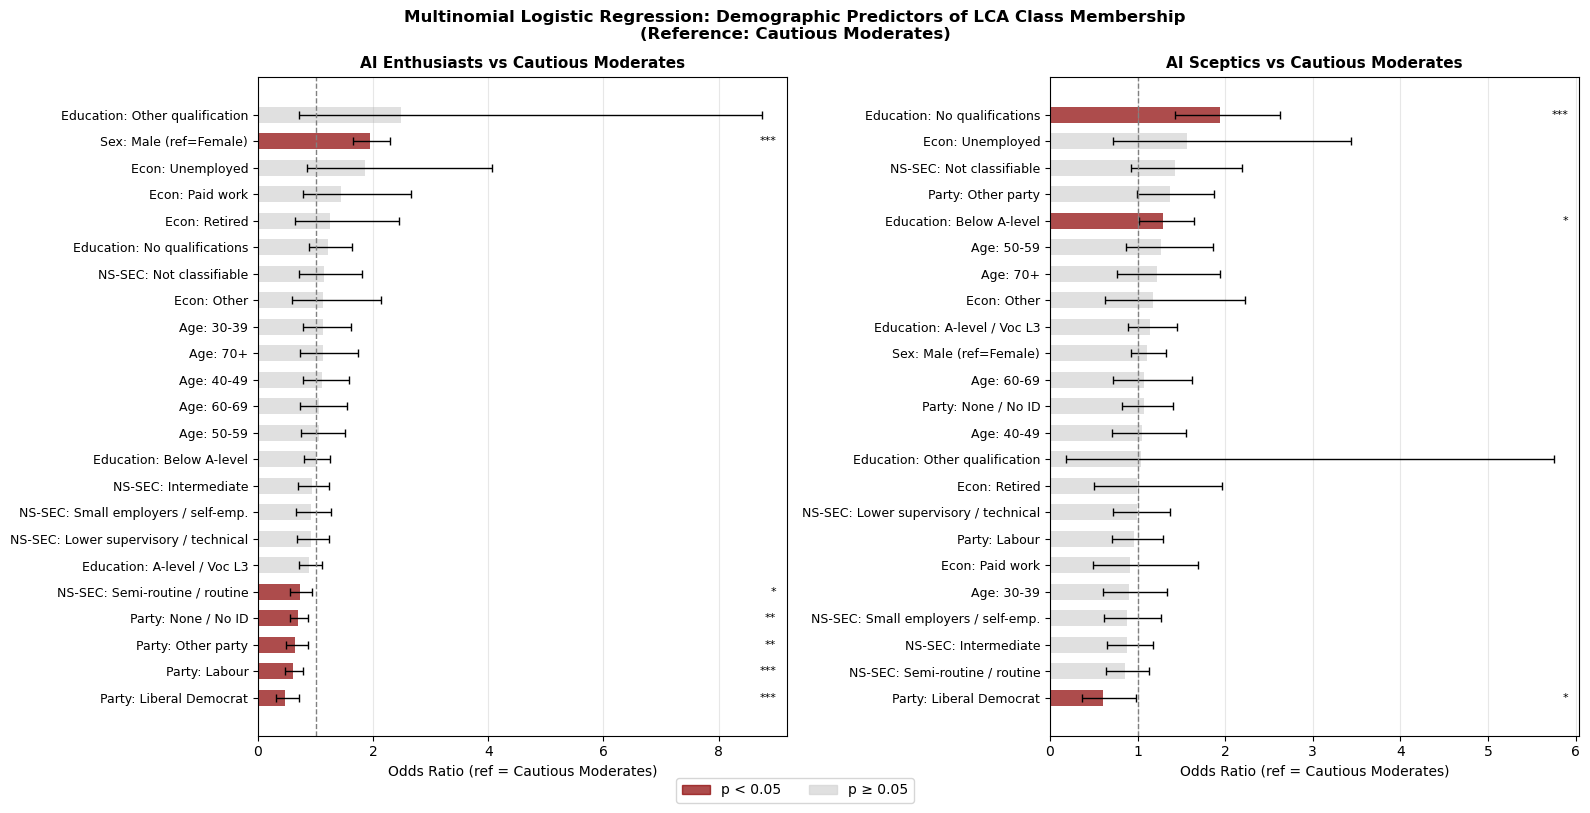

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=False)

plot_vars = [v for v in params.index if v != 'const']

panel_configs = [
    (0, '1', 'AI Enthusiasts vs Cautious Moderates', 'steelblue'),
    (1, '2', 'AI Sceptics vs Cautious Moderates',    'tomato'),
]

for ax, (param_col, conf_key, title, color) in zip(axes, panel_configs):
    coefs   = params[param_col][plot_vars]
    or_vals = np.exp(coefs)


    ci_low  = np.exp(conf.loc[(conf_key, plot_vars), 'lower'].values)
    ci_high = np.exp(conf.loc[(conf_key, plot_vars), 'upper'].values)
    p_vals  = pvals[param_col][plot_vars]

    # Sort by OR value ascending
    order          = np.argsort(or_vals.values)
    y_pos          = np.arange(len(plot_vars))
    labels_sorted  = [var_labels.get(plot_vars[i], plot_vars[i]) for i in order]
    or_sorted      = or_vals.values[order]
    ci_low_sorted  = ci_low[order]
    ci_high_sorted = ci_high[order]
    p_sorted       = p_vals.values[order]

    bar_colors = ['darkred' if p < 0.05 else 'lightgrey' for p in p_sorted]

    ax.barh(y_pos, or_sorted, color=bar_colors, alpha=0.7, height=0.6)
    ax.errorbar(
        or_sorted, y_pos,
        xerr=[or_sorted - ci_low_sorted, ci_high_sorted - or_sorted],
        fmt='none', color='black', capsize=3, linewidth=1
    )
    ax.axvline(x=1, color='grey', linestyle='--', linewidth=1)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels_sorted, fontsize=9)
    ax.set_xlabel('Odds Ratio (ref = Cautious Moderates)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

    for i, (p, y) in enumerate(zip(p_sorted, y_pos)):
        if p < 0.001:
            ax.text(ax.get_xlim()[1]*0.98, y, '***', ha='right', va='center', fontsize=8)
        elif p < 0.01:
            ax.text(ax.get_xlim()[1]*0.98, y, '**',  ha='right', va='center', fontsize=8)
        elif p < 0.05:
            ax.text(ax.get_xlim()[1]*0.98, y, '*',   ha='right', va='center', fontsize=8)

sig_patch   = mpatches.Patch(color='darkred',   alpha=0.7, label='p < 0.05')
insig_patch = mpatches.Patch(color='lightgrey', alpha=0.7, label='p ≥ 0.05')
fig.legend(handles=[sig_patch, insig_patch], loc='lower center',
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.suptitle(
    'Multinomial Logistic Regression: Demographic Predictors of LCA Class Membership\n'
    '(Reference: Cautious Moderates)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
#plt.savefig('6_mnlogit_or.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
print("Sample sizes for regression variables:")
print("\nParty ID distribution:")
print(df_reg['Cur_PartyID5'].value_counts().sort_index())

print("\nEducation distribution:")
print(df_reg['Cur_HEdQual'].value_counts().sort_index())

print("\nSocial class distribution:")
print(df_reg['Cur_RClassGp'].value_counts().sort_index())

# check the actual OR and CI for the outlier variables
print("\n ---- Outlier check ---")
for conf_key, param_col, label in [('1', 0, 'AI Enthusiasts'), ('2', 1, 'AI Sceptics')]:
    print(f"\n{label} (vs Cautious Moderates):")
    for var in ['Cur_PartyID5_3.0', 'Cur_HEdQual_4.0', 'Cur_RClassGp_8.0']:
        coef = params[param_col][var]
        lo   = conf.loc[(conf_key, var), 'lower']
        hi   = conf.loc[(conf_key, var), 'upper']
        p    = pvals[param_col][var]
        print(f"  {var}: OR={np.exp(coef):.2f}, CI=[{np.exp(lo):.2f}, {np.exp(hi):.2f}], p={p:.3f}")

Sample sizes for regression variables:

Party ID distribution:
Cur_PartyID5
1.0     603
2.0     727
3.0     160
4.0     470
5.0    1452
Name: count, dtype: int64

Education distribution:
Cur_HEdQual
1.0    1587
2.0     657
3.0     769
4.0      13
5.0     386
Name: count, dtype: int64

Social class distribution:
Cur_RClassGp
1.0    1941
2.0     358
3.0     231
4.0     303
5.0     432
8.0     147
Name: count, dtype: int64

 ---- Outlier check ---

AI Enthusiasts (vs Cautious Moderates):
  Cur_PartyID5_3.0: OR=0.47, CI=[0.31, 0.71], p=0.000
  Cur_HEdQual_4.0: OR=2.48, CI=[0.71, 8.75], p=0.157
  Cur_RClassGp_8.0: OR=1.14, CI=[0.72, 1.81], p=0.579

AI Sceptics (vs Cautious Moderates):
  Cur_PartyID5_3.0: OR=0.60, CI=[0.37, 0.98], p=0.041
  Cur_HEdQual_4.0: OR=1.04, CI=[0.19, 5.75], p=0.967
  Cur_RClassGp_8.0: OR=1.42, CI=[0.92, 2.20], p=0.112


In [40]:
# Robustness Check --- Split Sample Validation

from sklearn.model_selection import train_test_split
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

In [41]:
# random 50/50 split
SPLIT_SEED = 42
X_lca_A, X_lca_B, idx_A, idx_B = train_test_split(
    X_lca, np.arange(len(X_lca)),
    test_size=0.5, random_state=SPLIT_SEED
)
print(f"Sub-sample A: n={len(X_lca_A)}")
print(f"Sub-sample B: n={len(X_lca_B)}")
print(f"Total:        n={len(X_lca_A) + len(X_lca_B)}")

Sub-sample A: n=1756
Sub-sample B: n=1757
Total:        n=3513


In [42]:
# fit k=3 LCA on each half using the same procedure as the main model
# 
print("\n fitting LCA k=3 on Sub-sample A")
model_A = fit_best_model(X_lca_A, k=3, n_seeds=10)
print("fitting LCA k=3 on Sub-sample B")
model_B = fit_best_model(X_lca_B, k=3, n_seeds=10)

# report fit indices for each sub-sample solution
def report_fit(name, model, X, k=3):
    aic  = model.aic(X)
    bic  = model.bic(X)
    probs = model.predict_proba(X)
    entropy = 1 + (np.sum(probs * np.log(probs + 1e-10))) / (len(X) * np.log(k))
    print(f"{name:14s} AIC={aic:9.1f}  BIC={bic:9.1f}  Entropy={entropy:.3f}")

print("\n fit indices for k=3 solutions:")
report_fit('full sample',  model_k3, X_lca)
report_fit('Sub-sample A', model_A,  X_lca_A)
report_fit('Sub-sample B', model_B,  X_lca_B)


 fitting LCA k=3 on Sub-sample A
fitting LCA k=3 on Sub-sample B

 fit indices for k=3 solutions:
full sample    AIC= 120072.9  BIC= 121268.8  Entropy=0.818
Sub-sample A   AIC=  59640.2  BIC=  60701.5  Entropy=0.821
Sub-sample B   AIC=  60640.4  BIC=  61701.8  Entropy=0.827


In [43]:
# compute class conditional mean profiles for each solution
def get_profiles(model, X, recoded_vars):
    """return (k, 16) matrix of class-conditional means, indexed by raw class label """
    labels = model.predict(X)
    df = pd.DataFrame(X, columns=recoded_vars)
    df['class'] = labels
    return df.groupby('class')[recoded_vars].mean().values

full_profiles_raw = get_profiles(model_k3, X_lca, recoded_vars)
A_profiles_raw    = get_profiles(model_A,  X_lca_A, recoded_vars)
B_profiles_raw    = get_profiles(model_B,  X_lca_B, recoded_vars)

In [44]:
# align each sub-sample's classes to the full-sample reference by profile similarity
def align_to_reference(profiles_source, profiles_ref):
    """return dict mapping source_class_index -> reference_class_index."""
    dist = cdist(profiles_source, profiles_ref)  # shape (k_src, k_ref)
    row_ind, col_ind = linear_sum_assignment(dist)
    return dict(zip(row_ind, col_ind))

# Full-sample raw classes: 0=Enthusiasts, 1=Moderates, 2=Sceptics

ref_label_map = {0: 'AI Enthusiasts', 1: 'Cautious Moderates', 2: 'AI Sceptics'}

map_A = align_to_reference(A_profiles_raw, full_profiles_raw)
map_B = align_to_reference(B_profiles_raw, full_profiles_raw)
print(f"\nAlignment (Sub-sample A raw -> Full-sample class):")
for src, tgt in sorted(map_A.items()):
    print(f"  A raw class {src} -> Full class {tgt} ({ref_label_map[tgt]})")
print(f"Alignment (Sub-sample B raw -> Full-sample class):")
for src, tgt in sorted(map_B.items()):
    print(f"  B raw class {src} -> Full class {tgt} ({ref_label_map[tgt]})")

# reorder each sub-sample profile matrix so row j = reference class j
def reorder_profiles(profiles_raw, mapping):
    reordered = np.zeros_like(profiles_raw)
    for src, tgt in mapping.items():
        reordered[tgt] = profiles_raw[src]
    return reordered

A_profiles = reorder_profiles(A_profiles_raw, map_A)
B_profiles = reorder_profiles(B_profiles_raw, map_B)

# also apply mapping to labels for class-size comparison
labels_A_aligned = np.array([map_A[l] for l in model_A.predict(X_lca_A)])
labels_B_aligned = np.array([map_B[l] for l in model_B.predict(X_lca_B)])


Alignment (Sub-sample A raw -> Full-sample class):
  A raw class 0 -> Full class 2 (AI Sceptics)
  A raw class 1 -> Full class 1 (Cautious Moderates)
  A raw class 2 -> Full class 0 (AI Enthusiasts)
Alignment (Sub-sample B raw -> Full-sample class):
  B raw class 0 -> Full class 0 (AI Enthusiasts)
  B raw class 1 -> Full class 1 (Cautious Moderates)
  B raw class 2 -> Full class 2 (AI Sceptics)


In [45]:
# class prevalence comparison
print("\n=== class prevalence (full vs Sub-samples) ===")
print(f"{'Class':<22} {'Full n (%)':>15} {'A n (%)':>15} {'B n (%)':>15}")
for c in range(3):
    full_n   = int((df_lca['LCA_class'] == c+1).sum())
    full_pct = full_n / len(df_lca) * 100
    A_n      = int((labels_A_aligned == c).sum())
    A_pct    = A_n / len(labels_A_aligned) * 100
    B_n      = int((labels_B_aligned == c).sum())
    B_pct    = B_n / len(labels_B_aligned) * 100
    print(f"{ref_label_map[c]:<22} "
          f"{full_n:>6} ({full_pct:>4.1f}%)  "
          f"{A_n:>6} ({A_pct:>4.1f}%)  "
          f"{B_n:>6} ({B_pct:>4.1f}%)")


=== class prevalence (full vs Sub-samples) ===
Class                       Full n (%)         A n (%)         B n (%)
AI Enthusiasts           1109 (31.6%)     561 (31.9%)     523 (29.8%)
Cautious Moderates       1541 (43.9%)     735 (41.9%)     823 (46.8%)
AI Sceptics               863 (24.6%)     460 (26.2%)     411 (23.4%)


In [46]:
# profile similarity across sub-samples -- Pearson correlation of the 16-dim mean vectors
print("\n=== profile correlation across sub-samples ===")
print(f"{'Class':<22} {'r(Full,A)':>12} {'r(Full,B)':>12} {'r(A,B)':>10}")
for c in range(3):
    r_FA = np.corrcoef(full_profiles_raw[c], A_profiles[c])[0, 1]
    r_FB = np.corrcoef(full_profiles_raw[c], B_profiles[c])[0, 1]
    r_AB = np.corrcoef(A_profiles[c],        B_profiles[c])[0, 1]
    print(f"{ref_label_map[c]:<22} {r_FA:>12.3f} {r_FB:>12.3f} {r_AB:>10.3f}")


=== profile correlation across sub-samples ===
Class                     r(Full,A)    r(Full,B)     r(A,B)
AI Enthusiasts                1.000        0.999      0.998
Cautious Moderates            0.998        0.997      0.992
AI Sceptics                   0.998        0.997      0.989


In [47]:
# full profile means table (Full vs A vs B)
print("\n=== class profile means: full vs Sub-samples ===")
print(f"{'Variable':<15}"
      f"{'Enth-F':>8}{'Enth-A':>8}{'Enth-B':>8} | "
      f"{'Mod-F':>8}{'Mod-A':>8}{'Mod-B':>8} | "
      f"{'Scep-F':>8}{'Scep-A':>8}{'Scep-B':>8}")
for i, var in enumerate(recoded_vars):
    row = f"{var:<15}"
    for c in range(3):
        row += f"{full_profiles_raw[c, i]:>8.3f}{A_profiles[c, i]:>8.3f}{B_profiles[c, i]:>8.3f}"
        if c < 2: row += " | "
    print(row)


=== class profile means: full vs Sub-samples ===
Variable         Enth-F  Enth-A  Enth-B |    Mod-F   Mod-A   Mod-B |   Scep-F  Scep-A  Scep-B
BenFR_r           3.726   3.750   3.700 |    3.327   3.327   3.345 |    3.213   3.235   3.180
ConFR_r           1.800   1.811   1.759 |    2.457   2.471   2.425 |    2.603   2.539   2.708
BenWB_r           3.073   3.064   3.109 |    2.483   2.473   2.508 |    2.010   2.050   1.946
ConWB_r           2.087   2.118   2.036 |    2.875   2.865   2.861 |    3.282   3.211   3.372
BenCancer_r       3.794   3.784   3.811 |    3.350   3.348   3.366 |    3.175   3.217   3.122
ConCancer_r       1.628   1.674   1.558 |    2.369   2.382   2.348 |    2.552   2.474   2.633
BenLoan_r         3.101   3.111   3.076 |    2.725   2.703   2.776 |    2.204   2.224   2.168
ConLoan_r         1.998   2.034   1.954 |    2.667   2.682   2.637 |    3.010   2.957   3.066
BenLLM_r          3.256   3.235   3.291 |    2.897   2.906   2.889 |    2.334   2.383   2.294
ConLLM_r  

In [48]:
# average posterior probabilities (classification quality per sub-sample)
print("\n=== average posterior probability of assigned class ===")
for name, model, X_sub, mapping in [
    ('Sub-sample A', model_A, X_lca_A, map_A),
    ('Sub-sample B', model_B, X_lca_B, map_B),
]:
    probs = model.predict_proba(X_sub)
    labels_raw = model.predict(X_sub)
    print(f"\n{name}:")
    for aligned_c in range(3):
        raw_c = [k for k, v in mapping.items() if v == aligned_c][0]
        mask = labels_raw == raw_c
        avg_p = probs[mask, raw_c].mean() if mask.sum() > 0 else np.nan
        print(f"  {ref_label_map[aligned_c]:<22}: {avg_p:.3f} (n={mask.sum()})")


=== average posterior probability of assigned class ===

Sub-sample A:
  AI Enthusiasts        : 0.936 (n=561)
  Cautious Moderates    : 0.914 (n=735)
  AI Sceptics           : 0.907 (n=460)

Sub-sample B:
  AI Enthusiasts        : 0.928 (n=523)
  Cautious Moderates    : 0.914 (n=823)
  AI Sceptics           : 0.928 (n=411)


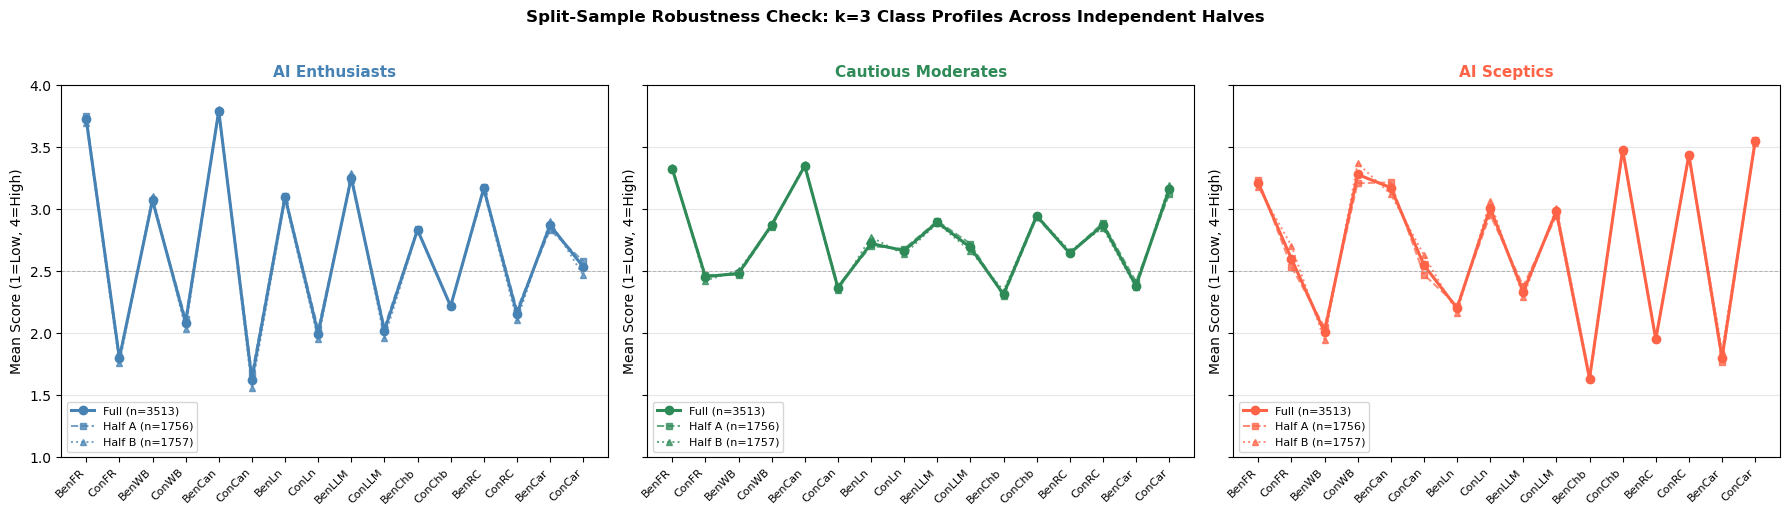

In [49]:
# visualization
class_colors_aligned = {0: 'steelblue', 1: 'seagreen', 2: 'tomato'}
short_labels = ['BenFR','ConFR','BenWB','ConWB','BenCan','ConCan',
                'BenLn','ConLn','BenLLM','ConLLM','BenChb','ConChb',
                'BenRC','ConRC','BenCar','ConCar']

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for c in range(3):
    ax = axes[c]
    x = np.arange(len(recoded_vars))
    ax.plot(x, full_profiles_raw[c], color=class_colors_aligned[c],
            linestyle='-', marker='o', linewidth=2.2, markersize=6,
            label=f'Full (n={len(X_lca)})')
    ax.plot(x, A_profiles[c], color=class_colors_aligned[c],
            linestyle='--', marker='s', linewidth=1.4, markersize=5, alpha=0.75,
            label=f'Half A (n={len(X_lca_A)})')
    ax.plot(x, B_profiles[c], color=class_colors_aligned[c],
            linestyle=':', marker='^', linewidth=1.4, markersize=5, alpha=0.75,
            label=f'Half B (n={len(X_lca_B)})')
    ax.set_xticks(x)
    ax.set_xticklabels(short_labels, fontsize=8, rotation=45, ha='right')
    ax.set_ylim(1, 4)
    ax.axhline(y=2.5, color='grey', linestyle='--', linewidth=0.7, alpha=0.5)
    ax.set_title(ref_label_map[c], fontsize=11, fontweight='bold',
                 color=class_colors_aligned[c])
    ax.set_ylabel('Mean Score (1=Low, 4=High)', fontsize=10)
    ax.legend(fontsize=8, loc='lower left')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Split-Sample Robustness Check: k=3 Class Profiles Across Independent Halves',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
#plt.savefig('7_split_sample_validation.png', dpi=150, bbox_inches='tight')
plt.show()

In [51]:
# Robustness Check ---- BCH Three-Step
# fit BCH + inspect API to locate coefficients

# build measurement and covariate matrices on the n=3412 subset used in two-step
mask_reg = df_lca.index.isin(df_reg.index)
X_lca_reg = df_lca.loc[mask_reg, recoded_vars].values.astype(int)

# covariate matrix

Z_cov_df = pd.get_dummies(
    df_reg[demo_vars_used].astype(str),
    drop_first=True,
    dtype=float
)
Z_cov = Z_cov_df.values
Z_cov_names = Z_cov_df.columns.tolist()

print(f"Measurement X shape:  {X_lca_reg.shape}")
print(f"Covariate  Z shape:  {Z_cov.shape}")
print(f"# covariate dummies:  {len(Z_cov_names)}")

# row alignment sanity check
assert X_lca_reg.shape[0] == Z_cov.shape[0] == 3412, "Row alignment failed"

Measurement X shape:  (3412, 16)
Covariate  Z shape:  (3412, 23)
# covariate dummies:  23


In [53]:
# fit BCH 3-step LCA
def fit_best_bch(X, Y, k, n_seeds=10, correction='BCH'):
    """3-step LCA with BCH correction; pick best fit by measurement BIC."""
    best_bic = np.inf
    best_model = None
    for seed in range(n_seeds):
        m = StepMix(
            n_components=k,
            n_steps=3,
            measurement='categorical',
            structural='covariate',
            assignment='modal',
            correction=correction,
            max_iter=500,
            random_state=seed,
            progress_bar=False,
            structural_params={
                'method': 'newton-raphson',
                'max_iter': 200,
                'intercept': True,
            },
        )
        m.fit(X, Y)
        # measurement-model BIC
        try:
            bic = m.bic(X)
        except TypeError:
            bic = m.bic(X, Y)
        if bic < best_bic:
            best_bic = bic
            best_model = m
    return best_model

print("\nFitting BCH 3-step with 10 random seeds")
model_bch = fit_best_bch(X_lca_reg, Z_cov, k=3, n_seeds=10, correction='BCH')

# convergence and class-size diagnostics
print("\n=== BCH model diagnostics ===")
print(f"Converged:            {model_bch.converged_}")
print(f"EM iterations:        {model_bch.n_iter_}")
print(f"Marginal class wts:   {np.round(model_bch.weights_, 4)}")

labels_bch = model_bch.predict(X_lca_reg)
print(f"\nBCH modal class sizes (raw indexing):")
for c in range(3):
    n = int((labels_bch == c).sum())
    print(f"  Raw class {c}: n={n} ({n/len(labels_bch)*100:.1f}%)")


Fitting BCH 3-step with 10 random seeds

=== BCH model diagnostics ===
Converged:            True
EM iterations:        51
Marginal class wts:   [0.4452 0.3098 0.245 ]

BCH modal class sizes (raw indexing):
  Raw class 0: n=1533 (44.9%)
  Raw class 1: n=1058 (31.0%)
  Raw class 2: n=821 (24.1%)


In [54]:
# verify class structure matches main model (model_k3) on n=3412 subset
def get_class_profiles(X, labels, recoded_vars):
    df = pd.DataFrame(X, columns=recoded_vars)
    df['class'] = labels
    return df.groupby('class')[recoded_vars].mean().values

# main model labels
labels_main_reg = df_lca.loc[mask_reg, 'LCA_class'].values - 1
profiles_main = get_class_profiles(X_lca_reg, labels_main_reg, recoded_vars)
profiles_bch  = get_class_profiles(X_lca_reg, labels_bch,      recoded_vars)

# hungarian alignment: BCH raw class -> main-model class
map_bch = align_to_reference(profiles_bch, profiles_main)

ref_label_map = {0: 'AI Enthusiasts', 1: 'Cautious Moderates', 2: 'AI Sceptics'}
print(f"\n=== class alignment: BCH raw class -> Main-model class ===")
for src, tgt in sorted(map_bch.items()):
    print(f"  BCH raw class {src} -> Main class {tgt} ({ref_label_map[tgt]})")

# profile correlations under alignment
print(f"\nprofile correlations")
for c_main in range(3):
    c_bch = [k for k, v in map_bch.items() if v == c_main][0]
    r = np.corrcoef(profiles_main[c_main], profiles_bch[c_bch])[0, 1]
    print(f"  {ref_label_map[c_main]:<22}: r(main, BCH) = {r:.4f}")

# compare marginal class prevalences between the two solutions on 3412
print(f"\n=== prevalence comparison on the n=3412 subset ===")
print(f"{'Class':<22} {'Main n (%)':>15} {'BCH n (%)':>15}")
for c in range(3):
    main_n = int((labels_main_reg == c).sum())
    c_bch = [k for k, v in map_bch.items() if v == c][0]
    bch_n = int((labels_bch == c_bch).sum())
    main_pct = main_n / len(labels_main_reg) * 100
    bch_pct  = bch_n  / len(labels_bch)      * 100
    print(f"{ref_label_map[c]:<22} {main_n:>6} ({main_pct:>4.1f}%)  "
          f"{bch_n:>6} ({bch_pct:>4.1f}%)")


=== class alignment: BCH raw class -> Main-model class ===
  BCH raw class 0 -> Main class 1 (Cautious Moderates)
  BCH raw class 1 -> Main class 0 (AI Enthusiasts)
  BCH raw class 2 -> Main class 2 (AI Sceptics)

profile correlations
  AI Enthusiasts        : r(main, BCH) = 1.0000
  Cautious Moderates    : r(main, BCH) = 0.9999
  AI Sceptics           : r(main, BCH) = 1.0000

=== prevalence comparison on the n=3412 subset ===
Class                       Main n (%)       BCH n (%)
AI Enthusiasts           1090 (31.9%)    1058 (31.0%)
Cautious Moderates       1496 (43.8%)    1533 (44.9%)
AI Sceptics               826 (24.2%)     821 (24.1%)


In [55]:
# locate the structural coefficients    probe API
print(f"\n=== Structural model (BCH) parameter inspection ===")
print(f"_sm type: {type(model_bch._sm).__name__}")

# use the public get_parameters() interface
try:
    all_params = model_bch.get_parameters()
    print(f"\nget_parameters() top-level keys: {list(all_params.keys())}")
    for k, v in all_params.items():
        if isinstance(v, dict):
            print(f"\n  '{k}' -> dict with keys {list(v.keys())}:")
            for kk, vv in v.items():
                if hasattr(vv, 'shape'):
                    print(f"    '{kk}': ndarray shape={vv.shape}")
                    print(f"       values:\n{np.round(np.asarray(vv), 3)}")
                else:
                    print(f"    '{kk}': {type(vv).__name__} = {vv}")
        elif hasattr(v, 'shape'):
            print(f"\n  '{k}': ndarray shape={v.shape}")
            print(np.round(np.asarray(v), 3))
        else:
            print(f"\n  '{k}': {type(v).__name__} = {v}")
except Exception as e:
    print(f"get_parameters() failed: {e}")

# fallback
print(f"\n_sm public non-callable attributes:")
for attr in sorted(dir(model_bch._sm)):
    if attr.startswith('_'):
        continue
    try:
        val = getattr(model_bch._sm, attr)
        if callable(val):
            continue
        if hasattr(val, 'shape'):
            print(f"  _sm.{attr}: shape={val.shape}")
        elif isinstance(val, (int, float, str, bool, np.number)):
            print(f"  _sm.{attr}: {val}")
        elif isinstance(val, dict):
            print(f"  _sm.{attr}: dict keys={list(val.keys())}")
    except Exception:
        pass


=== Structural model (BCH) parameter inspection ===
_sm type: Covariate

get_parameters() top-level keys: ['weights', 'measurement', 'measurement_in', 'structural', 'structural_in']

  'weights': ndarray shape=(3,)
[0.445 0.31  0.245]

  'measurement' -> dict with keys ['max_n_outcomes', 'total_outcomes', 'pis']:
    'max_n_outcomes': int = 5
    'total_outcomes': int = 80
    'pis': ndarray shape=(3, 80)
       values:
[[0.    0.006 0.036 0.574 0.384 0.    0.075 0.445 0.441 0.039 0.    0.047
  0.436 0.491 0.025 0.    0.005 0.209 0.708 0.078 0.    0.007 0.04  0.533
  0.42  0.    0.075 0.515 0.394 0.016 0.    0.012 0.292 0.653 0.043 0.
  0.014 0.354 0.597 0.036 0.    0.01  0.174 0.727 0.09  0.    0.015 0.349
  0.574 0.061 0.    0.064 0.565 0.36  0.012 0.    0.008 0.175 0.687 0.13
  0.    0.037 0.338 0.565 0.06  0.    0.007 0.236 0.637 0.119 0.    0.138
  0.395 0.403 0.064 0.    0.007 0.128 0.575 0.29 ]
 [0.    0.002 0.007 0.25  0.741 0.    0.396 0.444 0.136 0.023 0.    0.031
  0.111 0.

In [56]:
# coefficient alignment + comparison with two-step

# extract BCH beta and align class rows to conceptual class order

beta_bch_raw = model_bch.get_parameters()['structural']['beta']
print(f"Raw BCH beta shape: {beta_bch_raw.shape}")

# Build reverse map
inv_map_bch = {v: k for k, v in map_bch.items()}
print(f"Reverse alignment (main class -> BCH raw row): {inv_map_bch}")

# reorder beta -- row 0=Enthusiasts, row 1=Moderates, row 2=Sceptics
beta_bch = np.vstack([beta_bch_raw[inv_map_bch[c]] for c in range(3)])
print(f"Reordered BCH beta shape: {beta_bch.shape}")
print(f"  Row 0 = AI Enthusiasts  (was raw {inv_map_bch[0]})")
print(f"  Row 1 = Cautious Moderates (was raw {inv_map_bch[1]})")
print(f"  Row 2 = AI Sceptics    (was raw {inv_map_bch[2]})")

Raw BCH beta shape: (3, 24)
Reverse alignment (main class -> BCH raw row): {np.int64(1): np.int64(0), np.int64(0): np.int64(1), np.int64(2): np.int64(2)}
Reordered BCH beta shape: (3, 24)
  Row 0 = AI Enthusiasts  (was raw 1)
  Row 1 = Cautious Moderates (was raw 0)
  Row 2 = AI Sceptics    (was raw 2)


In [57]:
# verify column order

two_step_cols = X_reg.columns.tolist()
print(f"\nTwo-step X_reg columns ({len(two_step_cols)}):")
print(f"  First:  '{two_step_cols[0]}'")
print(f"  Dummies (1..): {two_step_cols[1:]}")

print(f"\nBCH covariate columns ({len(Z_cov_names)+1} with intercept):")
print(f"  First:  'intercept' (added by StepMix)")
print(f"  Dummies (Z_cov_names): {Z_cov_names}")

# assert dummy order matches
assert Z_cov_names == two_step_cols[1:], "Column order mismatch between BCH and two-step"
print("\nDummy column order matches: OK")


Two-step X_reg columns (24):
  First:  'const'
  Dummies (1..): ['Cur_Sex_2.0', 'Cur_AgeCat_2.0', 'Cur_AgeCat_3.0', 'Cur_AgeCat_4.0', 'Cur_AgeCat_5.0', 'Cur_AgeCat_6.0', 'Cur_HEdQual_2.0', 'Cur_HEdQual_3.0', 'Cur_HEdQual_4.0', 'Cur_HEdQual_5.0', 'Cur_PartyID5_2.0', 'Cur_PartyID5_3.0', 'Cur_PartyID5_4.0', 'Cur_PartyID5_5.0', 'Cur_RClassGp_2.0', 'Cur_RClassGp_3.0', 'Cur_RClassGp_4.0', 'Cur_RClassGp_5.0', 'Cur_RClassGp_8.0', 'Cur_EconAct5_2.0', 'Cur_EconAct5_3.0', 'Cur_EconAct5_4.0', 'Cur_EconAct5_5.0']

BCH covariate columns (24 with intercept):
  First:  'intercept' (added by StepMix)
  Dummies (Z_cov_names): ['Cur_Sex_2.0', 'Cur_AgeCat_2.0', 'Cur_AgeCat_3.0', 'Cur_AgeCat_4.0', 'Cur_AgeCat_5.0', 'Cur_AgeCat_6.0', 'Cur_HEdQual_2.0', 'Cur_HEdQual_3.0', 'Cur_HEdQual_4.0', 'Cur_HEdQual_5.0', 'Cur_PartyID5_2.0', 'Cur_PartyID5_3.0', 'Cur_PartyID5_4.0', 'Cur_PartyID5_5.0', 'Cur_RClassGp_2.0', 'Cur_RClassGp_3.0', 'Cur_RClassGp_4.0', 'Cur_RClassGp_5.0', 'Cur_RClassGp_8.0', 'Cur_EconAct5_2.0', '

In [58]:
# build contrasts (multinomial logit form) with Cautious Moderates as reference
#    contrast of class c vs reference = beta[c] - beta[Moderates]
bch_contrast_enth = beta_bch[0] - beta_bch[1]   # Ent vs Mod
bch_contrast_scep = beta_bch[2] - beta_bch[1]   # Sce vs Mod

# pull two-step estimates in matching order
two_step_enth = result.params[0].values
two_step_scep = result.params[1].values

# Sanity check   variable ordering
two_step_var_order = result.params.index.tolist()
bch_var_order = ['const'] + Z_cov_names
assert two_step_var_order == bch_var_order, "Variable name order mismatch"
print("\nVariable name order matches between two-step and BCH: OK")


Variable name order matches between two-step and BCH: OK


In [59]:
# comparison table
var_display = ['Intercept'] + [var_labels.get(v, v) for v in Z_cov_names]

def build_comparison(two_step_vec, bch_vec, label):
    rows = []
    for i, name in enumerate(var_display):
        rows.append({
            'Variable':    name,
            'Two-step':    round(two_step_vec[i], 3),
            'BCH':         round(bch_vec[i], 3),
            'Diff (BCH-2s)': round(bch_vec[i] - two_step_vec[i], 3),
            'OR_2step':    round(np.exp(two_step_vec[i]), 3),
            'OR_BCH':      round(np.exp(bch_vec[i]), 3),
        })
    return pd.DataFrame(rows)

comp_enth = build_comparison(two_step_enth, bch_contrast_enth, 'Enth vs Mod')
comp_scep = build_comparison(two_step_scep, bch_contrast_scep, 'Scep vs Mod')

print("\n" + "="*70)
print("AI ENTHUSIASTS vs CAUTIOUS MODERATES: two-step vs BCH")
print("="*70)
print(comp_enth.to_string(index=False))

print("\n" + "="*70)
print("AI SCEPTICS vs CAUTIOUS MODERATES: two-step vs BCH")
print("="*70)
print(comp_scep.to_string(index=False))


AI ENTHUSIASTS vs CAUTIOUS MODERATES: two-step vs BCH
                             Variable  Two-step    BCH  Diff (BCH-2s)  OR_2step  OR_BCH
                            Intercept    -0.613 -0.895         -0.282     0.542   0.409
               Sex: Male (ref=Female)     0.668  0.759          0.092     1.950   2.137
                           Age: 30-39     0.119  0.121          0.002     1.127   1.129
                           Age: 40-49     0.106  0.176          0.070     1.111   1.192
                           Age: 50-59     0.059  0.146          0.087     1.061   1.157
                           Age: 60-69     0.060  0.102          0.042     1.062   1.107
                             Age: 70+     0.119  0.135          0.016     1.126   1.145
          Education: A-level / Voc L3    -0.117 -0.119         -0.002     0.889   0.888
             Education: Below A-level     0.002 -0.011         -0.013     1.002   0.989
       Education: Other qualification     0.910  1.147          0

In [60]:
# overall agreement metrics
def agreement_stats(two_step_vec, bch_vec, label):
    slopes_2s  = two_step_vec[1:]   # drop intercept
    slopes_bch = bch_vec[1:]
    r_pearson  = np.corrcoef(slopes_2s, slopes_bch)[0, 1]
    # Spearman for rank agreement
    from scipy.stats import spearmanr
    r_spearman = spearmanr(slopes_2s, slopes_bch).correlation
    # mean absolute difference and RMSD
    mad  = np.mean(np.abs(slopes_bch - slopes_2s))
    rmsd = np.sqrt(np.mean((slopes_bch - slopes_2s) ** 2))
    # sign agreement
    sign_agree = np.mean(np.sign(slopes_2s) == np.sign(slopes_bch))
    print(f"\n{label} (23 slope coefficients, intercept excluded):")
    print(f"  Pearson r (log-odds):     {r_pearson:.4f}")
    print(f"  Spearman rho (log-odds):  {r_spearman:.4f}")
    print(f"  Mean |diff|:              {mad:.4f}")
    print(f"  RMSD:                     {rmsd:.4f}")
    print(f"  Sign agreement:           {sign_agree*100:.1f}% ({int(sign_agree*23)}/23)")
    return {'r': r_pearson, 'rho': r_spearman, 'mad': mad,
            'rmsd': rmsd, 'sign_pct': sign_agree}

print("\n" + "="*70)
print("OVERALL AGREEMENT (two-step vs BCH)")
print("="*70)
stats_enth = agreement_stats(two_step_enth, bch_contrast_enth, 'Enthusiasts vs Moderates')
stats_scep = agreement_stats(two_step_scep, bch_contrast_scep, 'Sceptics vs Moderates')


OVERALL AGREEMENT (two-step vs BCH)

Enthusiasts vs Moderates (23 slope coefficients, intercept excluded):
  Pearson r (log-odds):     0.9920
  Spearman rho (log-odds):  0.9783
  Mean |diff|:              0.0679
  RMSD:                     0.0933
  Sign agreement:           95.7% (22/23)

Sceptics vs Moderates (23 slope coefficients, intercept excluded):
  Pearson r (log-odds):     0.9796
  Spearman rho (log-odds):  0.9466
  Mean |diff|:              0.0548
  RMSD:                     0.0648
  Sign agreement:           95.7% (22/23)


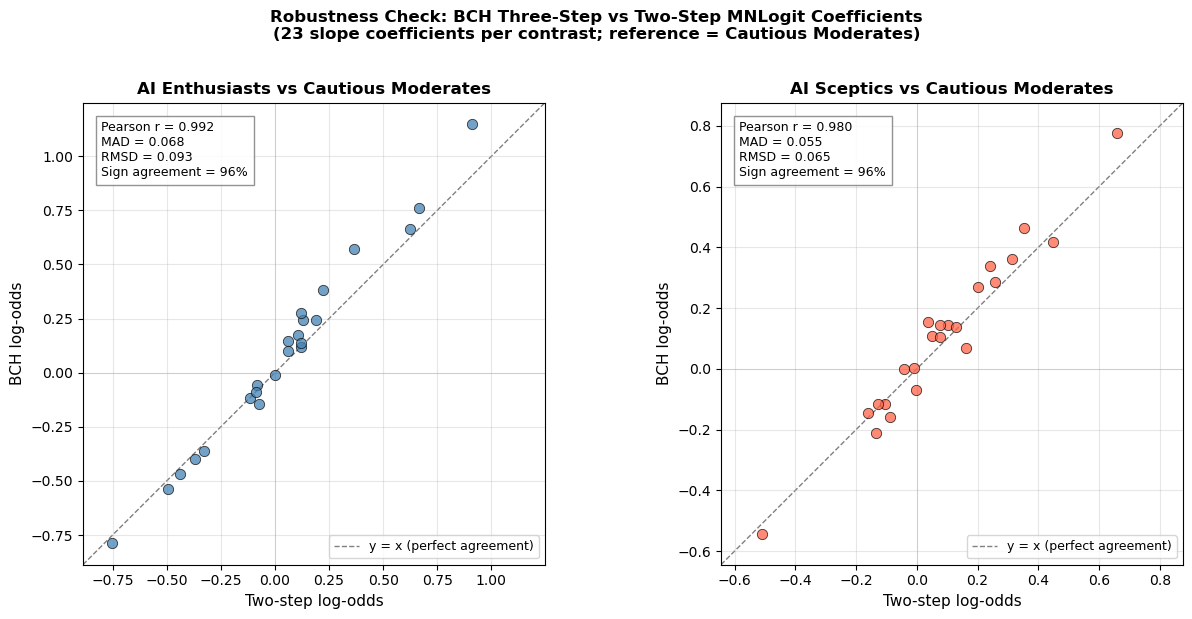

In [61]:
# Two-panel scatter plot: BCH log-odds vs two-step log-odds
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, (two_step_vec, bch_vec, title, color, stats) in zip(
    axes,
    [(two_step_enth, bch_contrast_enth,
      'AI Enthusiasts vs Cautious Moderates', 'steelblue', stats_enth),
     (two_step_scep, bch_contrast_scep,
      'AI Sceptics vs Cautious Moderates',    'tomato',    stats_scep)]
):
    # slopes only
    x = two_step_vec[1:]
    y = bch_vec[1:]

    # y = x reference
    lo = min(x.min(), y.min()) - 0.1
    hi = max(x.max(), y.max()) + 0.1
    ax.plot([lo, hi], [lo, hi], color='grey', linestyle='--', linewidth=1,
            label='y = x (perfect agreement)', zorder=1)
    ax.axhline(0, color='lightgrey', linewidth=0.6, zorder=0)
    ax.axvline(0, color='lightgrey', linewidth=0.6, zorder=0)

    ax.scatter(x, y, s=55, color=color, alpha=0.75, edgecolor='black',
               linewidth=0.6, zorder=2)

    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('Two-step log-odds', fontsize=11)
    ax.set_ylabel('BCH log-odds', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)

    # annotate agreement stats
    txt = (f"Pearson r = {stats['r']:.3f}\n"
           f"MAD = {stats['mad']:.3f}\n"
           f"RMSD = {stats['rmsd']:.3f}\n"
           f"Sign agreement = {stats['sign_pct']*100:.0f}%")
    ax.text(0.04, 0.96, txt, transform=ax.transAxes,
            fontsize=9, va='top', ha='left',
            bbox=dict(facecolor='white', edgecolor='grey', alpha=0.85))
    ax.legend(fontsize=9, loc='lower right')

plt.suptitle('Robustness Check: BCH Three-Step vs Two-Step MNLogit Coefficients\n'
             '(23 slope coefficients per contrast; reference = Cautious Moderates)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
#plt.savefig('8_bch_vs_two_step.png', dpi=150, bbox_inches='tight')
plt.show()

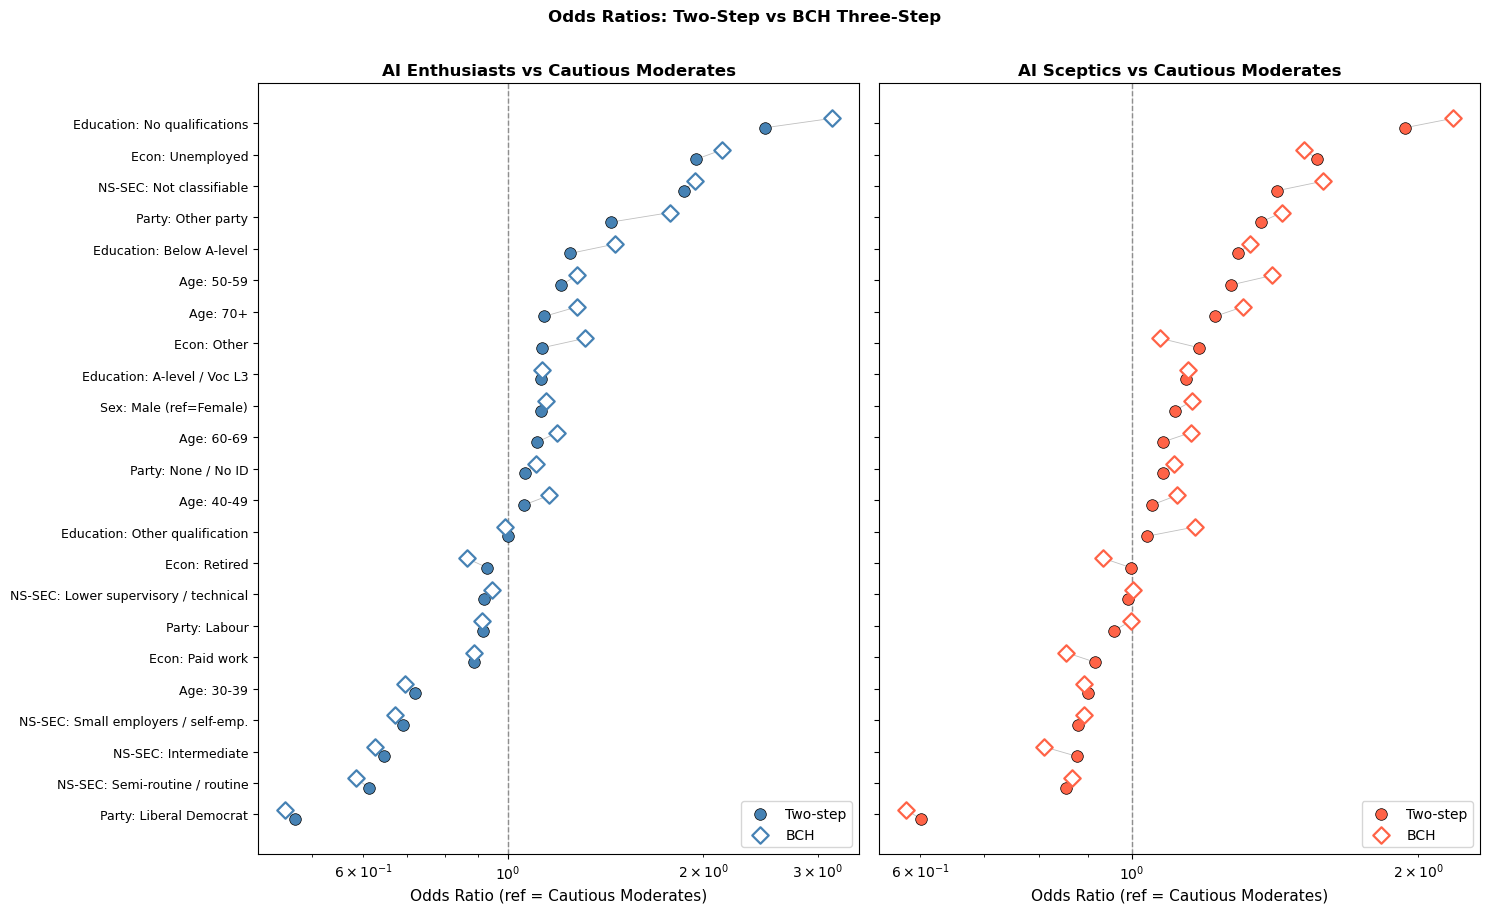

In [62]:
# Odds-ratio comparison plot for the substantively meaningful covariates

fig, axes = plt.subplots(1, 2, figsize=(15, 9), sharey=True)

for ax, (two_step_vec, bch_vec, title, color) in zip(
    axes,
    [(two_step_enth, bch_contrast_enth,
      'AI Enthusiasts vs Cautious Moderates', 'steelblue'),
     (two_step_scep, bch_contrast_scep,
      'AI Sceptics vs Cautious Moderates',    'tomato')]
):
    var_names_plot = [var_labels.get(v, v) for v in Z_cov_names]
    or_2s  = np.exp(two_step_vec[1:])
    or_bch = np.exp(bch_vec[1:])

    # sort by two-step OR for readability
    order = np.argsort(or_2s)
    y_pos = np.arange(len(var_names_plot))
    labels_sorted = [var_names_plot[i] for i in order]
    or_2s_s  = or_2s[order]
    or_bch_s = or_bch[order]

    ax.scatter(or_2s_s,  y_pos - 0.15, color=color, marker='o', s=70,
               label='Two-step', edgecolor='black', linewidth=0.5, zorder=3)
    ax.scatter(or_bch_s, y_pos + 0.15, color=color, marker='D', s=70,
               facecolor='white', edgecolor=color, linewidth=1.6,
               label='BCH', zorder=3)
    for i in range(len(y_pos)):
        ax.plot([or_2s_s[i], or_bch_s[i]], [y_pos[i]-0.15, y_pos[i]+0.15],
                color='grey', linewidth=0.6, alpha=0.5, zorder=2)
    ax.axvline(1, color='grey', linestyle='--', linewidth=1, zorder=1)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels_sorted, fontsize=9)
    ax.set_xlabel('Odds Ratio (ref = Cautious Moderates)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xscale('log')
    ax.grid(axis='x', alpha=0.3)
    ax.legend(fontsize=10, loc='lower right')

plt.suptitle('Odds Ratios: Two-Step vs BCH Three-Step',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
#plt.savefig('9_bch_or_comparison.png', dpi=150, bbox_inches='tight')
plt.show()